# 가설3: 장시간 유저(20h+) 분석 — 클리어 후 무엇이 달라지는가?

## 가설

> 메인스토리 클리어(~20h) 이후에도 플레이를 지속한 유저의 비판 리뷰는  
> 단순 불만이 아닌 **건설적이고 구체적인 피드백**을 담고 있으며,  
> 칭찬하는 요소 또한 라이트 유저와 **질적으로 다르다.**

## 이전 분석과의 연결

- **가설2 (라이트유저 분석)**: "클리어 전 모멘텀 이탈" 발견  
  — 이탈 유저는 "chill/relaxing", 엔딩 도달 유저는 "addictive/love/amazing" 키워드  
  — 캐주얼 즐거움과 감정적 몰입 사이의 갭 = 핵심 리텐션 문제
- **이번 분석**: "클리어 후에도 계속 한 유저들은 무엇을 칭찬/비판하는가?"

## 분석 철학

- 추측 배제, 데이터로 설득
- 가설이 기각될 수 있음을 전제 (Plan B 준비)
- "데이터가 말하는 것"과 "해석"을 명확히 분리
- 의사결정은 게임 디렉터의 몫임을 명시

## 데이터 레이어

| 레이어 | 테이블 | 규모 | 용도 |
|--------|--------|------|------|
| 전문 (전수) | `cleaned_reviews_en/ko` + `topic_assignments_en/ko` | EN 44,839 / KO 10,074 | 패턴 발견, 통계 견고 |
| 샘플 (LLM) | `neg_reviews_classified` (anthropic) | EN 556건 (20h+) | tone/category 의미 해석 |
| 샘플 (LLM) | `pos_reviews_classified` | EN+KO 1,167건 (20h+) | aspect/criticism 의미 해석 |

## 분석 흐름 (9 STEP)

```
STEP 0.  데이터 로드 + 변곡점 탐색 → 구간 확정
STEP 1.  전제 확인 — 긍정률 곡선 (맥락 제공, 짧게)
STEP 2.  [전문] LDA 토픽 구성비 변화
STEP 3.  [전문] 구간별 TF-IDF 특징 키워드
STEP 4.  [LLM 부정] tone 분포 변화 — 핵심 검증
STEP 5.  [LLM 부정] category 구성비 변화
STEP 6.  [LLM 부정] 건설적 비판 텍스트 직접 열람
STEP 7.  [LLM 긍정] aspect 구성비 변화
STEP 8.  영어 vs 한국어 교차 비교 (버터플라이)
STEP 9.  인사이트 종합
```

In [1]:
# 0-1. 임포트 + DB 연결
import sys, os, sqlite3, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

sys.path.append('..')
from config import DB_PATH

# 폰트 설정 (Mac)
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 120

db_path = os.path.join('..', DB_PATH)
conn = sqlite3.connect(db_path)
print(f' DB 연결: {db_path}')

 DB 연결: ../data/dave_diver.db


In [2]:
# 0-2. 전문 데이터 로드 (14h+ 전체)

full_en = pd.read_sql("""
    SELECT c.*, t.topic_id, t.topic_label
    FROM cleaned_reviews_en c
    LEFT JOIN topic_assignments_en t ON c.review_id = t.review_id
    WHERE c.playtime_hours >= 14
""", conn)
print(f"영어 전문 (14h+): {len(full_en):,}건")

full_ko = pd.read_sql("""
    SELECT c.*, t.topic_id, t.topic_label
    FROM cleaned_reviews_ko c
    LEFT JOIN topic_assignments_ko t ON c.review_id = t.review_id
    WHERE c.playtime_hours >= 14
""", conn)
print(f"한국어 전문 (14h+): {len(full_ko):,}건")

# LLM 분류 데이터
neg_full = pd.read_sql("""
    SELECT n.*, r.playtime_forever, r.playtime_at_review AS playtime_at_review_raw
    FROM neg_reviews_classified n
    JOIN reviews r ON n.review_id = r.review_id
    WHERE n.classify_method = 'anthropic'
      AND n.playtime_hours >= 14
""", conn)
print(f"부정 LLM (anthropic, 14h+): {len(neg_full):,}건")

pos_full = pd.read_sql("""
    SELECT p.*, r.playtime_forever, r.playtime_at_review AS playtime_at_review_raw
    FROM pos_reviews_classified p
    JOIN reviews r ON p.review_id = r.review_id
    WHERE p.playtime_hours >= 14
""", conn)
print(f"긍정 LLM (14h+): {len(pos_full):,}건")

# 토픽 정의 로드
topic_defs = pd.read_sql("SELECT * FROM topic_definitions", conn)
print(f"\n토픽 정의: {len(topic_defs)}건")

영어 전문 (14h+): 26,614건
한국어 전문 (14h+): 5,911건
부정 LLM (anthropic, 14h+): 958건
긍정 LLM (14h+): 1,611건

토픽 정의: 12건


=== 빈별 리뷰 수 (진단용) ===
  14-16h: 1721건
  16-18h: 1536건
  18-20h: 1392건
  20-22h: 1363건
  22-24h: 1283건
  24-26h: 1229건
  26-28h: 1211건
  28-30h: 1118건
  30-32h: 1209건
  32-34h: 1075건
  34-36h: 1040건
  36-38h: 989건
  38-40h: 892건
  40-42h: 870건
  42-44h: 795건
  44-46h: 741건
  46-48h: 632건
  48-50h: 587건
  50-52h: 608건
  52-54h: 496건
  54-56h: 475건
  56-58h: 390건
  58-60h: 378건
  60-62h: 368건
  62-64h: 335건
  64-66h: 279건
  66-68h: 283건
  68-70h: 224건



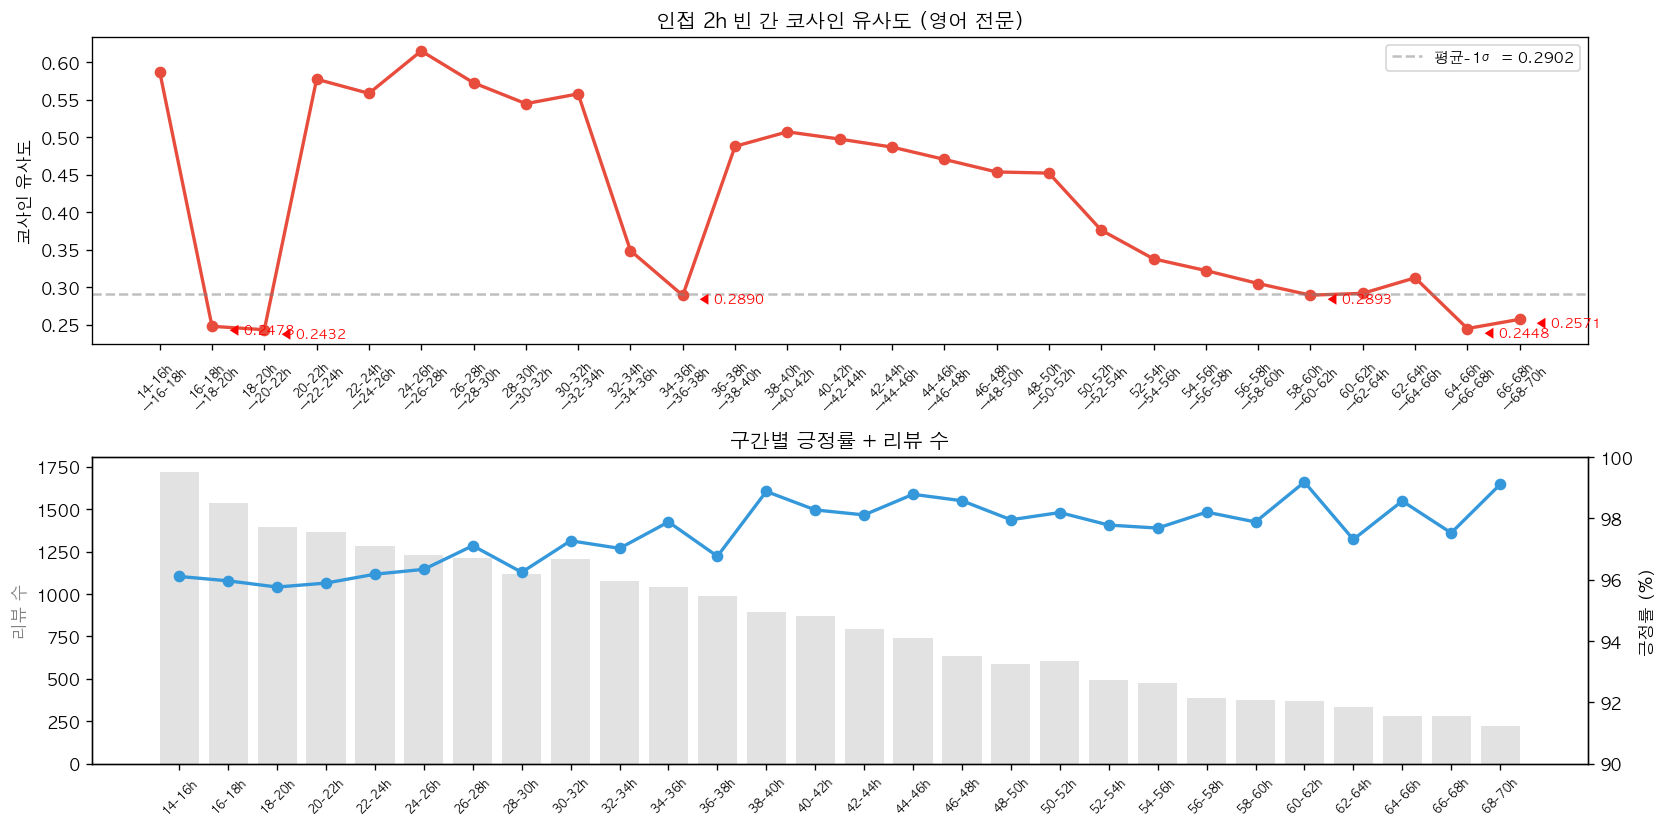


=== 코사인 유사도 (인접 빈) ===
  14-16h → 16-18h: 0.5874
  16-18h → 18-20h: 0.2478 ◀ 급락
  18-20h → 20-22h: 0.2432 ◀ 급락
  20-22h → 22-24h: 0.5775
  22-24h → 24-26h: 0.5586
  24-26h → 26-28h: 0.6152
  26-28h → 28-30h: 0.5727
  28-30h → 30-32h: 0.5448
  30-32h → 32-34h: 0.5579
  32-34h → 34-36h: 0.3488
  34-36h → 36-38h: 0.2890 ◀ 급락
  36-38h → 38-40h: 0.4879
  38-40h → 40-42h: 0.5073
  40-42h → 42-44h: 0.4976
  42-44h → 44-46h: 0.4869
  44-46h → 46-48h: 0.4705
  46-48h → 48-50h: 0.4537
  48-50h → 50-52h: 0.4522
  50-52h → 52-54h: 0.3761
  52-54h → 54-56h: 0.3378
  54-56h → 56-58h: 0.3222
  56-58h → 58-60h: 0.3049
  58-60h → 60-62h: 0.2893 ◀ 급락
  60-62h → 62-64h: 0.2917
  62-64h → 64-66h: 0.3125
  64-66h → 66-68h: 0.2448 ◀ 급락
  66-68h → 68-70h: 0.2571 ◀ 급락

평균: 0.4161, 표준편차: 0.1259
임계값 (평균-1σ): 0.2902


In [3]:
# 0-3. 코사인 유사도 기반 변곡점 탐색 (14h ~ 70h, 2h 단위 빈)

# 14~70을 2시간 간격으로 쪼개서, 각 리뷰에 "이 사람은 몇 시간 구간 유저인가" 라벨 붙이기
bins_2h = list(range(14, 72, 2))
bin_labels_2h = [f'{b}-{b+2}h' for b in bins_2h[:-1]]

full_en['bin_2h'] = pd.cut(full_en['playtime_hours'], bins=bins_2h, labels=bin_labels_2h, right=False)
binned = full_en.dropna(subset=['bin_2h'])

# 빈별 리뷰 수 먼저 확인 ──
bin_counts = binned.groupby('bin_2h', observed=True).size()
print("=== 빈별 리뷰 수 (진단용) ===")
for b, cnt in bin_counts.items():
    flag = " 적음" if cnt < 50 else ""
    print(f"  {b}: {cnt}건{flag}")
print()

# 같은 구간에 속한 리뷰를 모두 합쳐서 TF-IDF로 벡터화
# min_df=2: 각 빈이 하나의 문서이므로 min_df=5는 너무 높음 → 2로 완화
vectorizer = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.9, stop_words='english')
#전체 어휘 중 TF-IDF점수 상위 3000개의 단어만 사용. 28개 빈중 최소 3개의 빈에서 등장한 단어만 사용하기, 90%이상 너무 흔하게 등장하는 단어는 제외, 불용어제거
all_texts = binned.groupby('bin_2h', observed=True)['cleaned_text'].apply(' '.join)
valid_bins = all_texts[all_texts.str.len() > 0].index.tolist()
all_texts = all_texts[valid_bins]

tfidf_matrix = vectorizer.fit_transform(all_texts)

# 인접 빈 간 코사인 유사도 계산
similarities = []
for i in range(len(valid_bins) - 1):
    sim = cosine_similarity(tfidf_matrix[i:i+1], tfidf_matrix[i+1:i+2])[0][0]
    similarities.append({'from': valid_bins[i], 'to': valid_bins[i+1], 'similarity': sim})
sim_df = pd.DataFrame(similarities)

# 빈별 긍정률 + 건수
bin_stats = binned.groupby('bin_2h', observed=True).agg(
    count=('voted_up', 'size'),
    pos_rate=('voted_up', 'mean')
).loc[valid_bins]
bin_stats['pos_rate'] = bin_stats['pos_rate'] * 100

# 시각화: 2행 subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# 상단: 코사인 유사도
ax1.plot(range(len(sim_df)), sim_df['similarity'], 'o-', color='#E74C3C', linewidth=2, markersize=6)
ax1.set_ylabel('코사인 유사도')
ax1.set_title('인접 2h 빈 간 코사인 유사도 (영어 전문)')
ax1.set_xticks(range(len(sim_df)))
ax1.set_xticklabels([f"{r['from']}\n→{r['to']}" for _, r in sim_df.iterrows()], fontsize=7, rotation=45)
threshold = sim_df['similarity'].mean() - sim_df['similarity'].std()
ax1.axhline(y=threshold, color='gray', linestyle='--', alpha=0.5, label=f'평균-1σ = {threshold:.4f}')
for i, row in sim_df.iterrows():
    if row['similarity'] < threshold:
        ax1.annotate(f"◀ {row['similarity']:.4f}", (i, row['similarity']),
                     textcoords="offset points", xytext=(10, -5), fontsize=8, color='red')
ax1.legend(fontsize=9)

# 하단: 긍정률 + 리뷰 수
ax2b = ax2.twinx()
# 막대그래프 - 리뷰 수
ax2.bar(range(len(bin_stats)), bin_stats['count'], color='#d0d0d0', alpha=0.6)
ax2.set_ylabel('리뷰 수', color='gray')
# 꺾은선 그래프 - 긍정률
ax2b.plot(range(len(bin_stats)), bin_stats['pos_rate'], 'o-', color='#3498DB', linewidth=2)
ax2b.set_ylabel('긍정률 (%)')
ax2b.set_ylim(90, 100)
ax2.set_xticks(range(len(bin_stats)))
ax2.set_xticklabels(bin_stats.index, fontsize=7, rotation=45)
ax2.set_title('구간별 긍정률 + 리뷰 수')

plt.tight_layout()
figures_dir = os.path.join('..', 'reports', 'figures')
os.makedirs(figures_dir, exist_ok=True)
fig.savefig(os.path.join(figures_dir, 'long_player_step0_inflection.png'), dpi=150, bbox_inches='tight')
plt.show()

# 변곡점 후보 출력
print("\n=== 코사인 유사도 (인접 빈) ===")
for _, row in sim_df.iterrows():
    marker = " ◀ 급락" if row['similarity'] < threshold else ""
    print(f"  {row['from']} → {row['to']}: {row['similarity']:.4f}{marker}")
print(f"\n평균: {sim_df['similarity'].mean():.4f}, 표준편차: {sim_df['similarity'].std():.4f}")
print(f"임계값 (평균-1σ): {threshold:.4f}")


In [4]:
# 0-4. LLM 샘플 빈별 건수 확인

print("=== 부정 LLM (anthropic) 빈별 건수 ===")
for lang in ['english', 'korean']:
    sub = neg_full[neg_full['language_group'] == lang]
    sub_binned = pd.cut(sub['playtime_hours'],
                        bins=[14, 20, 25, 30, 40, 50, 70, 9999],
                        labels=['15-20h','20-25h','25-30h','30-40h','40-50h','50-70h','70h+'],
                        right=False)
    print(f"\n  [{lang}] 총 {len(sub)}건")
    print(sub_binned.value_counts().sort_index().to_string())

print("\n\n=== 긍정 LLM 빈별 건수 ===")
for lang in ['english', 'korean']:
    sub = pos_full[pos_full['language_group'] == lang]
    sub_binned = pd.cut(sub['playtime_hours'],
                        bins=[15, 20, 25, 30, 40, 50, 70, 9999],
                        labels=['15-20h','20-25h','25-30h','30-40h','40-50h','50-70h','70h+'],
                        right=False)
    print(f"\n  [{lang}] 총 {len(sub)}건")
    print(sub_binned.value_counts().sort_index().to_string())

=== 부정 LLM (anthropic) 빈별 건수 ===

  [english] 총 744건
playtime_hours
15-20h    188
20-25h    126
25-30h    101
30-40h    129
40-50h     60
50-70h     73
70h+       67

  [korean] 총 161건
playtime_hours
15-20h    47
20-25h    32
25-30h    18
30-40h    28
40-50h    10
50-70h    14
70h+      12


=== 긍정 LLM 빈별 건수 ===

  [english] 총 1224건
playtime_hours
15-20h    241
20-25h    241
25-30h    173
30-40h    149
40-50h    100
50-70h    125
70h+      126

  [korean] 총 387건
playtime_hours
15-20h    105
20-25h     65
25-30h     37
30-40h     48
40-50h     28
50-70h     38
70h+       37


### 0-5. LONG_SEGMENTS 확정

위 코사인 유사도 급락 지점과 LLM 샘플 건수를 확인한 후, 아래 셀에서 구간을 확정하세요.

**구간 설정 원칙:**
1. 코사인 유사도 급락 지점 = 텍스트 내용이 질적으로 변하는 경계
2. 각 구간의 LLM 샘플이 최소 30건 이상 (영어 기준)
3. `near_clear` (15-20h)는 비교 기준선으로 고정

In [5]:
# 0-5. 구간 확정 — 코사인 유사도 결과를 보고 아래 값을 수정하세요
# (기본값은 예상 구간입니다. 데이터 확인 후 변곡점에 맞게 조정)

LONG_SEGMENTS = {
    'near_clear':   (15, 20),   # 기준선: 클리어 직전 경계
    'post_clear':   (20, 36),   # 클리어 직후 (코사인 유사도 36h 변곡점)
    'deep_play':    (36, 50),   # 딥 플레이 (36~50h)
    'hardcore':     (50, 9999), # 하드코어 : 
}

SEGMENT_LABELS_KO = {
    'near_clear':   '기준선 (15-20h)',
    'post_clear':   '클리어 후 (20-36h)',
    'deep_play':    '딥 플레이 (36-50h)',
    'hardcore':     '하드코어 (50h+)',
}

# 색상 상수
ASPECT_COLORS = {
    'atmosphere': '#DDA0DD',
    'gameplay_fun': '#FF6B6B',
    'story_charm': '#4ECDC4',
    'variety': '#45B7D1',
    'value': '#FFEAA7',
    'polish': '#96CEB4',
    'other_positive': '#C0C0C0',
}

CATEGORY_COLORS = {
    'gameplay': '#E74C3C',
    'technical': '#3498DB',
    'repetition': '#F39C12',
    'story_content': '#9B59B6',
    'company': '#1ABC9C',
    'forced_neg': '#7F8C8D',
    'other': '#95A5A6',
}

TONE_COLORS = {
    'constructive': '#2ECC71',
    'mixed': '#F39C12',
    'emotional': '#E74C3C',
    'troll': '#95A5A6',
}

# 구간 컬럼 생성 함수
def assign_segment(hours, segments=LONG_SEGMENTS):
    for name, (lo, hi) in segments.items():
        if lo <= hours < hi:
            return name
    return None

# 모든 데이터에 구간 배정
for df in [full_en, full_ko, neg_full, pos_full]:
    df['segment'] = df['playtime_hours'].apply(assign_segment)

# 구간별 건수 확인
print("=== 확정 구간 ===")
for seg, (lo, hi) in LONG_SEGMENTS.items():
    hi_str = f"{hi}h" if hi < 9999 else "∞"
    en_n = len(full_en[full_en['segment'] == seg])
    ko_n = len(full_ko[full_ko['segment'] == seg])
    neg_en_n = len(neg_full[(neg_full['segment'] == seg) & (neg_full['language_group'] == 'english')])
    neg_ko_n = len(neg_full[(neg_full['segment'] == seg) & (neg_full['language_group'] == 'korean')])
    pos_n = len(pos_full[pos_full['segment'] == seg])
    print(f"  {seg} ({lo}~{hi_str}): 전문EN={en_n:,} / 전문KO={ko_n:,} / negEN={neg_en_n} / negKO={neg_ko_n} / pos={pos_n}")

# 구간 순서
SEGMENT_ORDER = list(LONG_SEGMENTS.keys())

# 분류값 순서 (후속 STEP에서 공통 사용)
cat_order = ['gameplay', 'story_content', 'repetition', 'technical', 'company', 'forced_neg', 'other']
aspect_order = ['atmosphere', 'gameplay_fun', 'story_charm', 'variety', 'value', 'polish', 'other_positive']


=== 확정 구간 ===
  near_clear (15~20h): 전문EN=3,715 / 전문KO=1,089 / negEN=149 / negKO=40 / pos=346
  post_clear (20~36h): 전문EN=9,528 / 전문KO=2,187 / negEN=314 / negKO=70 / pos=632
  deep_play (36~50h): 전문EN=5,506 / 전문KO=1,065 / negEN=102 / negKO=18 / pos=209
  hardcore (50~∞): 전문EN=6,931 / 전문KO=1,298 / negEN=140 / negKO=26 / pos=326


---
## STEP 1. 전제 확인 — 긍정률 곡선

**목적:** 20h+ 유저의 긍정률이 안정적인지 확인 → "비율 변화가 아닌 내용 변화 추적"의 근거 마련  
**데이터:** `cleaned_reviews_en` (10h~60h 구간)

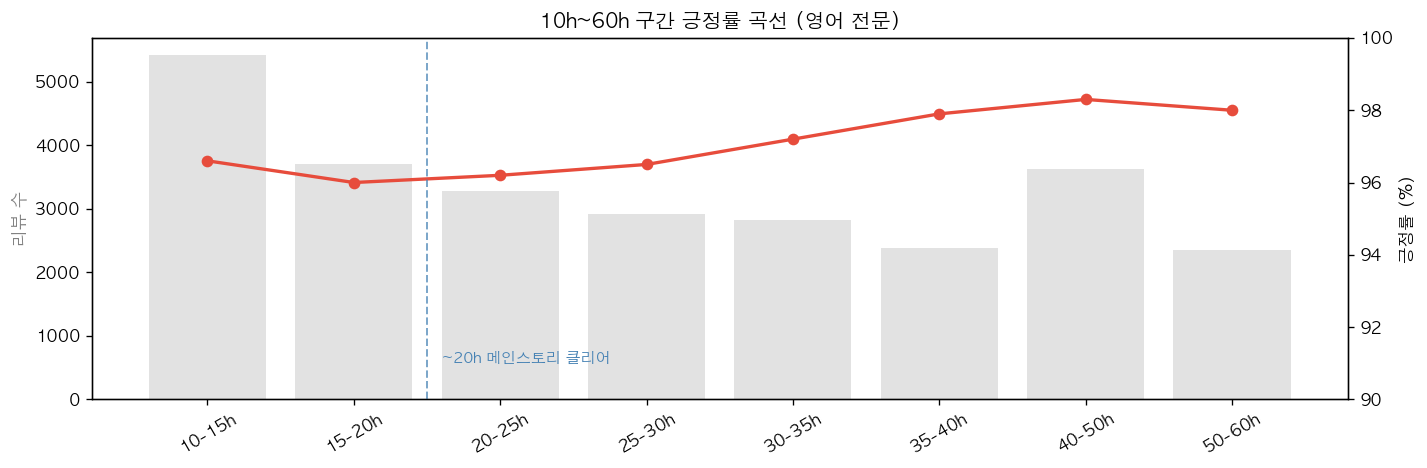

  band  total  pos_rate
10-15h   5422      96.6
15-20h   3715      96.0
20-25h   3277      96.2
25-30h   2927      96.5
30-35h   2822      97.2
35-40h   2383      97.9
40-50h   3625      98.3
50-60h   2347      98.0


In [6]:
# STEP 1. 긍정률 곡선 (10h~60h)

rate_df = pd.read_sql("""
    SELECT
        CASE
            WHEN playtime_hours < 15 THEN '10-15h'
            WHEN playtime_hours < 20 THEN '15-20h'
            WHEN playtime_hours < 25 THEN '20-25h'
            WHEN playtime_hours < 30 THEN '25-30h'
            WHEN playtime_hours < 35 THEN '30-35h'
            WHEN playtime_hours < 40 THEN '35-40h'
            WHEN playtime_hours < 50 THEN '40-50h'
            WHEN playtime_hours < 60 THEN '50-60h'
        END as band,
        COUNT(*) as total,
        ROUND(AVG(voted_up) * 100, 1) as pos_rate
    FROM cleaned_reviews_en
    WHERE playtime_hours >= 10 AND playtime_hours < 60
    GROUP BY band
    ORDER BY MIN(playtime_hours)
""", conn)

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.bar(rate_df['band'], rate_df['total'], color='#d0d0d0', alpha=0.6, label='리뷰 수')
ax1.set_ylabel('리뷰 수', color='gray')
ax1.tick_params(axis='x', rotation=30)

ax2 = ax1.twinx()
ax2.plot(rate_df['band'], rate_df['pos_rate'], color='#E74C3C', marker='o', linewidth=2, label='긍정률')
ax2.set_ylabel('긍정률 (%)')
ax2.set_ylim(90, 100)

# 20h 기준선
ax2.axvline(x=1.5, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(1.6, 91, '~20h 메인스토리 클리어', color='steelblue', fontsize=9)

plt.title('10h~60h 구간 긍정률 곡선 (영어 전문)')
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step1_posrate.png'), dpi=150, bbox_inches='tight')
plt.show()

print(rate_df.to_string(index=False))



---
## STEP 2. [전문] LDA 토픽 구성비 변화

**목적:** 플레이타임 구간별로 어떤 주제가 더 많이 논의되는지 확인  
**데이터:** `cleaned_reviews_en/ko` + `topic_assignments_en/ko`, LONG_SEGMENTS 기준 구간화

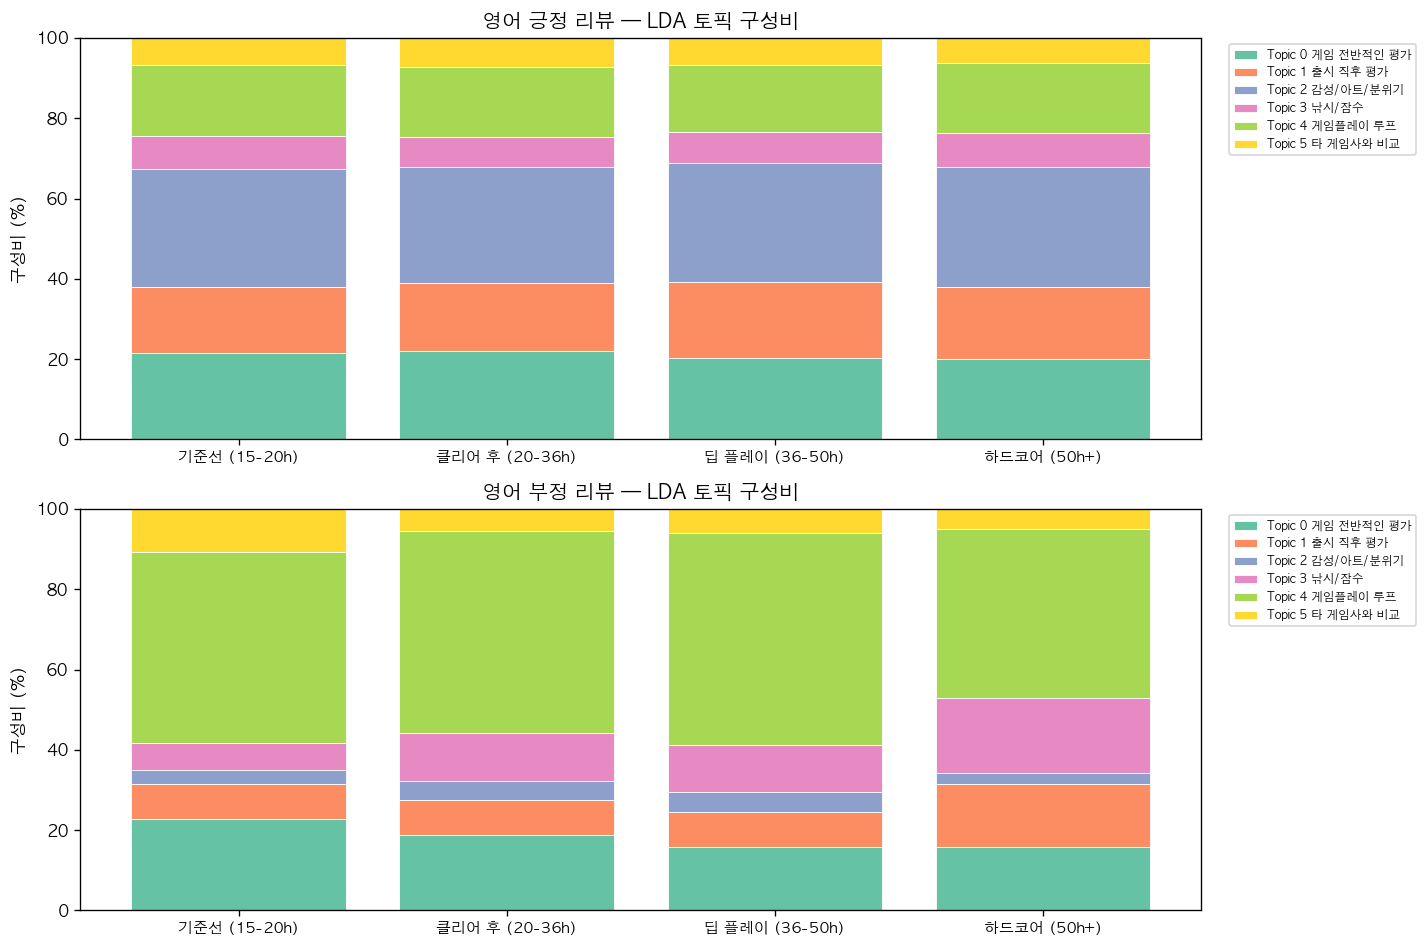


=== 영어 긍정 토픽 구성비 (%) ===
topic_label  Topic 0 게임 전반적인 평가  Topic 1 출시 직후 평가  Topic 2 감성/아트/분위기  Topic 3 낚시/잠수  Topic 4 게임플레이 루프  Topic 5 타 게임사와 비교
segment                                                                                                                 
near_clear                 21.4              16.6               29.3            8.2              17.7                6.7
post_clear                 21.9              17.1               28.8            7.7              17.4                7.2
deep_play                  20.3              18.9               29.7            7.7              16.7                6.7
hardcore                   20.0              18.0               29.7            8.4              17.7                6.1

=== 영어 부정 토픽 구성비 (%) ===
topic_label  Topic 0 게임 전반적인 평가  Topic 1 출시 직후 평가  Topic 2 감성/아트/분위기  Topic 3 낚시/잠수  Topic 4 게임플레이 루프  Topic 5 타 게임사와 비교
segment                                                                                              

In [7]:
# STEP 2. LDA 토픽 구성비 변화 (영어: 긍정/부정 분리)

# 토픽 색상 팔레트
topic_labels_en = topic_defs[topic_defs['language'] == 'english'].sort_values('topic_id')
n_topics = len(topic_labels_en)
topic_cmap = plt.cm.Set2(np.linspace(0, 1, max(n_topics, 8)))
topic_colors = {row['label']: topic_cmap[i] for i, (_, row) in enumerate(topic_labels_en.iterrows())}

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax_idx, (voted_up_val, title) in enumerate([(1, '긍정 리뷰'), (0, '부정 리뷰')]):
    ax = axes[ax_idx]
    sub = full_en[(full_en['voted_up'] == voted_up_val) & (full_en['segment'].notna())].copy()
    
    if len(sub) == 0:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # 구간별 토픽 구성비
    ct = pd.crosstab(sub['segment'], sub['topic_label'], normalize='index') * 100
    ct = ct.reindex(SEGMENT_ORDER).dropna(how='all')
    
    # 100% stacked bar
    bottom = np.zeros(len(ct))
    for col in ct.columns:
        color = topic_colors.get(col, '#888888')
        ax.bar(range(len(ct)), ct[col], bottom=bottom, label=col[:25], color=color, edgecolor='white', linewidth=0.5)
        bottom += ct[col].values
    
    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels([SEGMENT_LABELS_KO.get(s, s) for s in ct.index], fontsize=9)
    ax.set_ylabel('구성비 (%)')
    ax.set_title(f'영어 {title} — LDA 토픽 구성비')
    ax.set_ylim(0, 100)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step2_lda_topic.png'), dpi=150, bbox_inches='tight')
plt.show()

# 수치 출력
for voted_up_val, label in [(1, '긍정'), (0, '부정')]:
    sub = full_en[(full_en['voted_up'] == voted_up_val) & (full_en['segment'].notna())]
    ct = pd.crosstab(sub['segment'], sub['topic_label'], normalize='index') * 100
    ct = ct.reindex(SEGMENT_ORDER).dropna(how='all').round(1)
    print(f"\n=== 영어 {label} 토픽 구성비 (%) ===")
    print(ct.to_string())

---
## STEP 3. [전문] 구간별 TF-IDF 특징 키워드

**목적:** 각 구간에서만 유독 많이 등장하는 키워드 추출 → "이 구간 유저는 무슨 이야기를 하는가?"  
**방법:** target 빈 vs 나머지의 TF-IDF 평균 벡터 차이 → 상위 N개 추출

In [8]:
# STEP 3. 구간별 TF-IDF 특징 키워드

def extract_distinctive_keywords(df, segment_col, text_col, target_seg, n=15):
    """target 구간 vs 나머지 구간의 TF-IDF 차이가 큰 키워드 추출"""
    target_texts = df[df[segment_col] == target_seg][text_col].dropna()
    other_texts = df[df[segment_col] != target_seg][text_col].dropna()
    
    if len(target_texts) < 10 or len(other_texts) < 10:
        return pd.DataFrame({'keyword': [], 'score': []})
    
    vec = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8, stop_words='english')
    all_corpus = pd.concat([target_texts, other_texts])
    vec.fit(all_corpus)
    
    target_vec = vec.transform(target_texts).mean(axis=0).A1
    other_vec = vec.transform(other_texts).mean(axis=0).A1
    
    diff = target_vec - other_vec
    feature_names = vec.get_feature_names_out()
    top_idx = diff.argsort()[-n:][::-1]
    
    return pd.DataFrame({
        'keyword': feature_names[top_idx],
        'score': diff[top_idx]
    })

# 영어 구간별 특징 키워드
print("=== 영어 구간별 특징 키워드 (TF-IDF 차이 Top 15) ===")
en_segmented = full_en[full_en['segment'].notna()].copy()
keyword_results_en = {}

for seg in SEGMENT_ORDER:
    kw = extract_distinctive_keywords(en_segmented, 'segment', 'cleaned_text', seg, n=15)
    keyword_results_en[seg] = kw
    label = SEGMENT_LABELS_KO.get(seg, seg)
    print(f"\n[{label}]")
    if len(kw) > 0:
        for _, row in kw.iterrows():
            print(f"  {row['keyword']:20s} (+{row['score']:.4f})")
    else:
        print("  (데이터 부족)")

# 한국어 구간별 특징 키워드
print("\n\n=== 한국어 구간별 특징 키워드 ===")
ko_segmented = full_ko[full_ko['segment'].notna()].copy()
keyword_results_ko = {}

for seg in SEGMENT_ORDER:
    kw = extract_distinctive_keywords(ko_segmented, 'segment', 'cleaned_text', seg, n=15)
    keyword_results_ko[seg] = kw
    label = SEGMENT_LABELS_KO.get(seg, seg)
    print(f"\n[{label}]")
    if len(kw) > 0:
        for _, row in kw.iterrows():
            print(f"  {row['keyword']:20s} (+{row['score']:.4f})")
    else:
        print("  (데이터 부족)")

=== 영어 구간별 특징 키워드 (TF-IDF 차이 Top 15) ===

[기준선 (15-20h)]
  fish                 (+0.0071)
  fun                  (+0.0052)
  access               (+0.0046)
  early                (+0.0043)
  wait                 (+0.0034)
  release              (+0.0033)
  deep                 (+0.0020)
  diving               (+0.0020)
  addict               (+0.0020)
  addictive            (+0.0017)
  deck                 (+0.0017)
  far                  (+0.0017)
  depth                (+0.0017)
  loop                 (+0.0016)
  bug                  (+0.0015)

[클리어 후 (20-36h)]
  amazing              (+0.0019)
  diving               (+0.0018)
  release              (+0.0014)
  mechanic             (+0.0013)
  chill                (+0.0013)
  new                  (+0.0013)
  guy                  (+0.0012)
  incredible           (+0.0012)
  man                  (+0.0012)
  buy                  (+0.0012)
  addicting            (+0.0011)
  cool                 (+0.0011)
  water                (+0.0010)
 

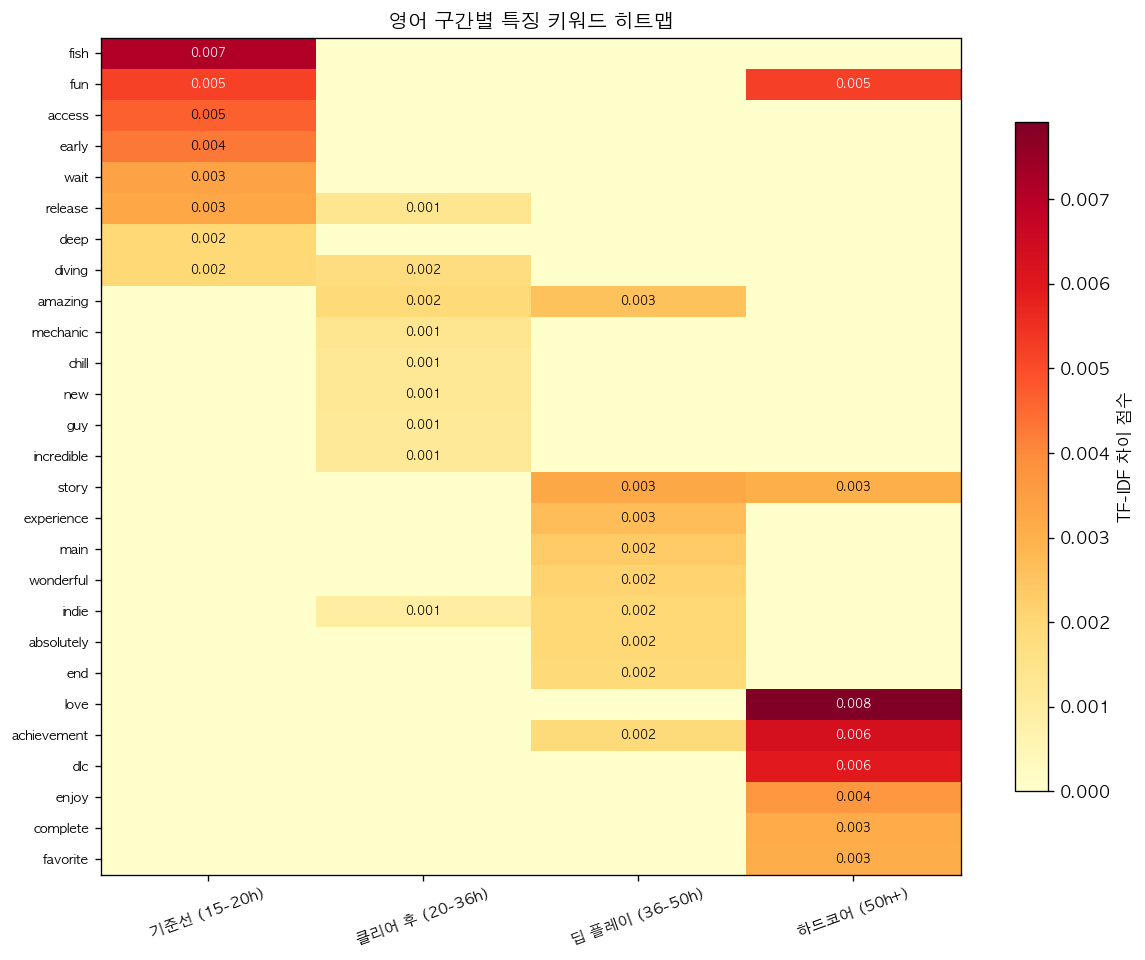

In [9]:
# STEP 3 히트맵 — 구간별 특징 키워드 강도

# 영어 히트맵 데이터 구성
all_keywords = []
for seg in SEGMENT_ORDER:
    kw = keyword_results_en[seg]
    if len(kw) > 0:
        all_keywords.extend(kw['keyword'].head(8).tolist())
all_keywords = list(dict.fromkeys(all_keywords))  # 중복 제거, 순서 유지

heatmap_data = pd.DataFrame(index=all_keywords, columns=SEGMENT_ORDER, dtype=float).fillna(0)
for seg in SEGMENT_ORDER:
    kw = keyword_results_en[seg]
    for _, row in kw.iterrows():
        if row['keyword'] in heatmap_data.index:
            heatmap_data.loc[row['keyword'], seg] = row['score']

fig, ax = plt.subplots(figsize=(10, max(6, len(all_keywords) * 0.3)))
cmap = plt.cm.YlOrRd

im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto')
ax.set_xticks(range(len(SEGMENT_ORDER)))
ax.set_xticklabels([SEGMENT_LABELS_KO.get(s, s) for s in SEGMENT_ORDER], fontsize=9, rotation=20)
ax.set_yticks(range(len(all_keywords)))
ax.set_yticklabels(all_keywords, fontsize=8)

# 수치 표시
for i in range(len(all_keywords)):
    for j in range(len(SEGMENT_ORDER)):
        val = heatmap_data.values[i, j]
        if val > 0.0005:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7,
                    color='white' if val > heatmap_data.values.max() * 0.6 else 'black')

plt.colorbar(im, ax=ax, label='TF-IDF 차이 점수', shrink=0.8)
ax.set_title('영어 구간별 특징 키워드 히트맵')
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step3_keyword_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 4. [LLM 부정] tone 분포 변화 — 핵심 검증

**이 분석의 중심 가설 검증 스텝**

> 가설: 30h+ 유저의 constructive 비율이 기준선(15-20h)보다 유의미하게 높다

**판정 기준 (코드 실행 전 명시):**
- **가설 지지**: constructive 비율이 구간이 올라갈수록 증가하고, chi-square 검정 p < 0.05
- **가설 기각**: constructive 비율에 유의미한 차이 없음 → STEP 5에서 "tone보다 category 구성이 달라진다"로 프레이밍 변경

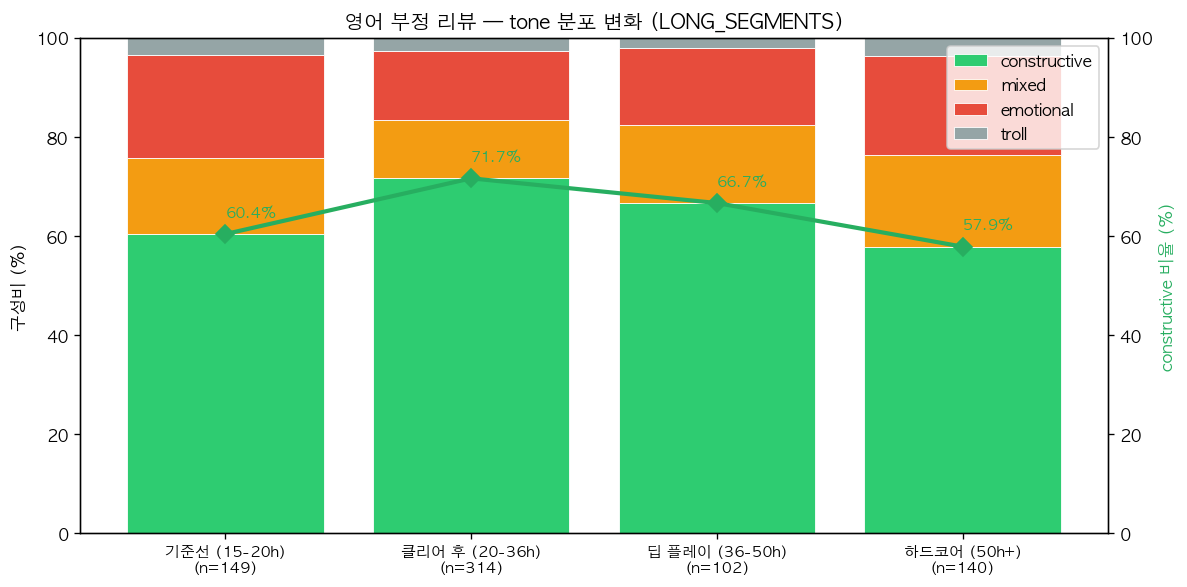


=== tone 구성비 (%) ===
tone        constructive  emotional  mixed  troll
segment                                          
near_clear          60.4       20.8   15.4    3.4
post_clear          71.7       14.0   11.8    2.5
deep_play           66.7       15.7   15.7    2.0
hardcore            57.9       20.0   18.6    3.6

=== 건수 ===
tone        constructive  emotional  mixed  troll
segment                                          
near_clear            90         31     23      5
post_clear           225         44     37      8
deep_play             68         16     16      2
hardcore              81         28     26      5

=== Chi-square 검정 ===
  χ² = 11.60, p = 0.2366, dof = 9
  → p ≥ 0.05: 구간별 tone 분포에 유의미한 차이가 없다

표준화 잔차 (|값| > 2 → 유의미):
tone        constructive  emotional  mixed  troll
segment                                          
near_clear         -0.81       1.17   0.31   0.38
post_clear          1.28      -1.24  -1.25  -0.30
deep_play           0.11      -0.29   0.32  -

In [10]:
# STEP 4. tone 분포 변화 (영어 부정 리뷰)
from scipy.stats import chi2_contingency

neg_en = neg_full[neg_full['language_group'] == 'english'].copy()
neg_en_seg = neg_en[neg_en['segment'].notna()].copy()

# 구간별 tone 구성비
tone_ct = pd.crosstab(neg_en_seg['segment'], neg_en_seg['tone'])
tone_ct = tone_ct.reindex(SEGMENT_ORDER).dropna(how='all')
tone_pct = tone_ct.div(tone_ct.sum(axis=1), axis=0) * 100

# 시각화: Stacked bar + constructive 비율 라인
fig, ax1 = plt.subplots(figsize=(10, 5))

tone_order = ['constructive', 'mixed', 'emotional', 'troll']
bottom = np.zeros(len(tone_pct))
for tone in tone_order:
    if tone in tone_pct.columns:
        vals = tone_pct[tone].values
        ax1.bar(range(len(tone_pct)), vals, bottom=bottom,
                color=TONE_COLORS.get(tone, '#888'), label=tone, edgecolor='white', linewidth=0.5)
        bottom += vals

ax1.set_xticks(range(len(tone_pct)))
ax1.set_xticklabels([f"{SEGMENT_LABELS_KO.get(s, s)}\n(n={tone_ct.loc[s].sum()})" for s in tone_pct.index], fontsize=9)
ax1.set_ylabel('구성비 (%)')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right')

# constructive 비율 라인 오버레이
ax2 = ax1.twinx()
if 'constructive' in tone_pct.columns:
    ax2.plot(range(len(tone_pct)), tone_pct['constructive'].values,
             'D-', color='#27AE60', linewidth=2.5, markersize=8, label='constructive %')
    for i, val in enumerate(tone_pct['constructive'].values):
        ax2.annotate(f'{val:.1f}%', (i, val), textcoords="offset points",
                     xytext=(0, 10), fontsize=9, fontweight='bold', color='#27AE60')
ax2.set_ylabel('constructive 비율 (%)', color='#27AE60')
ax2.set_ylim(0, 100)

ax1.set_title('영어 부정 리뷰 — tone 분포 변화 (LONG_SEGMENTS)')
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step4_tone.png'), dpi=150, bbox_inches='tight')
plt.show()

# Chi-square 검정
print("\n=== tone 구성비 (%) ===")
print(tone_pct.round(1).to_string())

print("\n=== 건수 ===")
print(tone_ct.to_string())

# 기준선 vs 나머지 chi-square
if len(tone_ct) >= 2:
    chi2, p, dof, expected = chi2_contingency(tone_ct)
    print(f"\n=== Chi-square 검정 ===")
    print(f"  χ² = {chi2:.2f}, p = {p:.4f}, dof = {dof}")
    if p < 0.05:
        print(f"  → p < 0.05: 구간별 tone 분포에 통계적으로 유의미한 차이가 있다")
    else:
        print(f"  → p ≥ 0.05: 구간별 tone 분포에 유의미한 차이가 없다")
    
    # 표준화 잔차
    residuals = (tone_ct.values - expected) / np.sqrt(expected)
    res_df = pd.DataFrame(residuals, index=tone_ct.index, columns=tone_ct.columns).round(2)
    print("\n표준화 잔차 (|값| > 2 → 유의미):")
    print(res_df.to_string())

### STEP 4 판정

> **실행 후 결과를 보고 아래 해석을 작성할 것**
> - constructive 비율이 구간별로 어떻게 변하는가?
> - chi-square p 값은?  
> - 가설 지지 / 기각 여부

---
## STEP 5. [LLM 부정] category 구성비 변화

**목적:** 구간별로 어떤 종류의 불만이 주를 이루는지 파악  
**추가 확인:** `actual_sentiment = 'positive_but_negative_vote'` 비율 → "오래 했지만 넥슨 때문에 비추"  
**데이터:** `neg_reviews_classified` (anthropic), 영어 + 한국어

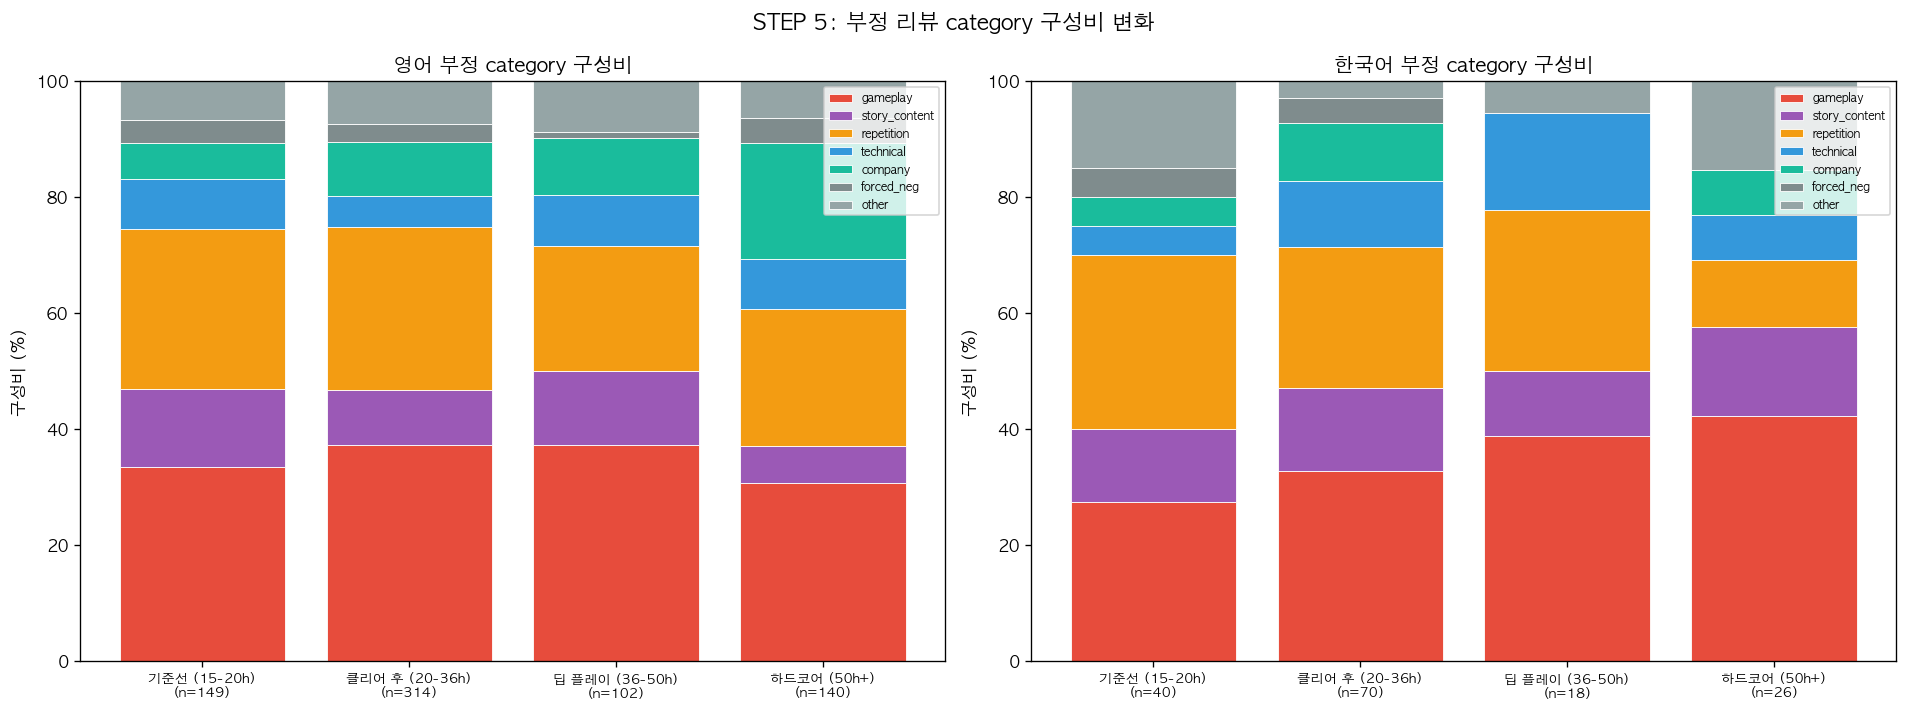


=== 영어 category 구성비 (%) ===
category    company  forced_neg  gameplay  other  repetition  story_content  technical
segment                                                                               
near_clear      6.0         4.0      33.6    6.7        27.5           13.4        8.7
post_clear      9.2         3.2      37.3    7.3        28.0            9.6        5.4
deep_play       9.8         1.0      37.3    8.8        21.6           12.7        8.8
hardcore       20.0         4.3      30.7    6.4        23.6            6.4        8.6

=== 한국어 category 구성비 (%) ===
category    company  forced_neg  gameplay  other  repetition  story_content  technical
segment                                                                               
near_clear      5.0         5.0      27.5   15.0        30.0           12.5        5.0
post_clear     10.0         4.3      32.9    2.9        24.3           14.3       11.4
deep_play       0.0         0.0      38.9    5.6        27.8           

In [11]:
# STEP 5-1. category 구성비 변화 (영어/한국어 subplot)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, lang in enumerate(['english', 'korean']):
    ax = axes[ax_idx]
    sub = neg_full[(neg_full['language_group'] == lang) & (neg_full['segment'].notna())].copy()
    
    if len(sub) < 10:
        ax.text(0.5, 0.5, f'{lang}: 데이터 부족', ha='center', va='center', transform=ax.transAxes)
        continue
    
    cat_ct = pd.crosstab(sub['segment'], sub['category'])
    cat_ct = cat_ct.reindex(SEGMENT_ORDER).dropna(how='all')
    cat_pct = cat_ct.div(cat_ct.sum(axis=1), axis=0) * 100
    
    bottom = np.zeros(len(cat_pct))
    for cat in cat_order:
        if cat in cat_pct.columns:
            vals = cat_pct[cat].values
            ax.bar(range(len(cat_pct)), vals, bottom=bottom,
                   color=CATEGORY_COLORS.get(cat, '#888'), label=cat, edgecolor='white', linewidth=0.5)
            bottom += vals
    
    ax.set_xticks(range(len(cat_pct)))
    ax.set_xticklabels([f"{SEGMENT_LABELS_KO.get(s, s)}\n(n={cat_ct.loc[s].sum()})" for s in cat_pct.index],
                       fontsize=8)
    ax.set_ylabel('구성비 (%)')
    ax.set_ylim(0, 100)
    lang_label = '영어' if lang == 'english' else '한국어'
    ax.set_title(f'{lang_label} 부정 category 구성비')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('STEP 5: 부정 리뷰 category 구성비 변화', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step5_category.png'), dpi=150, bbox_inches='tight')
plt.show()

# 수치 출력
for lang in ['english', 'korean']:
    sub = neg_full[(neg_full['language_group'] == lang) & (neg_full['segment'].notna())]
    if len(sub) < 5:
        continue
    cat_ct = pd.crosstab(sub['segment'], sub['category'])
    cat_ct = cat_ct.reindex(SEGMENT_ORDER).dropna(how='all')
    cat_pct = cat_ct.div(cat_ct.sum(axis=1), axis=0) * 100
    lang_label = '영어' if lang == 'english' else '한국어'
    print(f"\n=== {lang_label} category 구성비 (%) ===")
    print(cat_pct.round(1).to_string())

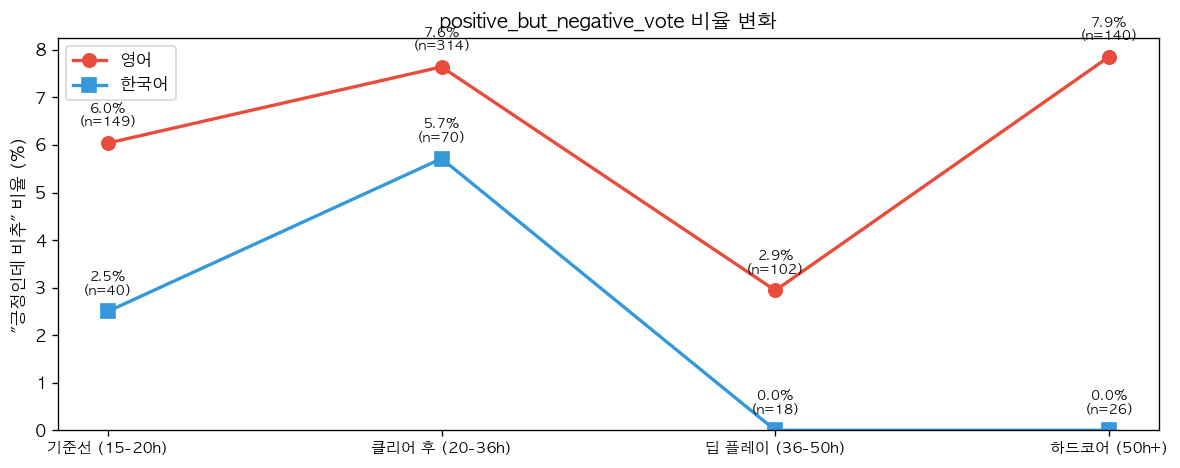

=== positive_but_negative_vote 비율 ===

[영어]
            count  pbnv  pbnv_pct
segment                          
near_clear  149.0   9.0       6.0
post_clear  314.0  24.0       7.6
deep_play   102.0   3.0       2.9
hardcore    140.0  11.0       7.9

[한국어]
            count  pbnv  pbnv_pct
segment                          
near_clear   40.0   1.0       2.5
post_clear   70.0   4.0       5.7
deep_play    18.0   0.0       0.0
hardcore     26.0   0.0       0.0


In [12]:
# STEP 5-2. positive_but_negative_vote 비율 변화

fig, ax = plt.subplots(figsize=(10, 4))

for lang, color, marker in [('english', '#E74C3C', 'o'), ('korean', '#3498DB', 's')]:
    sub = neg_full[(neg_full['language_group'] == lang) & (neg_full['segment'].notna())].copy()
    if len(sub) < 10:
        continue
    
    pbnv = sub.groupby('segment').apply(
        lambda x: (x['actual_sentiment'] == 'positive_but_negative_vote').mean() * 100
    ).reindex(SEGMENT_ORDER).dropna()
    
    counts = sub.groupby('segment').size().reindex(SEGMENT_ORDER).dropna()
    
    lang_label = '영어' if lang == 'english' else '한국어'
    ax.plot(range(len(pbnv)), pbnv.values, f'{marker}-', color=color, linewidth=2,
            markersize=8, label=lang_label)
    
    for i, (seg, val) in enumerate(pbnv.items()):
        n = counts[seg]
        ax.annotate(f'{val:.1f}%\n(n={n})', (i, val),
                    textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

ax.set_xticks(range(len(SEGMENT_ORDER)))
ax.set_xticklabels([SEGMENT_LABELS_KO.get(s, s) for s in SEGMENT_ORDER], fontsize=9)
ax.set_ylabel('"긍정인데 비추" 비율 (%)')
ax.set_title('positive_but_negative_vote 비율 변화')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step5_pbnv.png'), dpi=150, bbox_inches='tight')
plt.show()

# 수치 출력
print("=== positive_but_negative_vote 비율 ===")
for lang in ['english', 'korean']:
    sub = neg_full[(neg_full['language_group'] == lang) & (neg_full['segment'].notna())]
    pbnv = sub.groupby('segment').apply(
        lambda x: pd.Series({
            'count': len(x),
            'pbnv': (x['actual_sentiment'] == 'positive_but_negative_vote').sum(),
            'pbnv_pct': (x['actual_sentiment'] == 'positive_but_negative_vote').mean() * 100
        })
    ).reindex(SEGMENT_ORDER).dropna()
    lang_label = '영어' if lang == 'english' else '한국어'
    print(f"\n[{lang_label}]")
    print(pbnv.round(1).to_string())

---
### STEP 5-3. "좋지만 비추" 심층 분석 — post_clear(20-36h) 구간 집중

**배경:** post_clear 구간에서 `positive_but_negative_vote` 비율이 7.6%로 최고치  
→ "게임이 재밌다고 쓰면서 왜 비추를 눌렀는가?" — 텍스트 직접 열람으로 원인 파악


In [13]:
# STEP 5-3. "좋지만 비추" — post_clear(20-36h) 영어 전문 샘플링

pbnv_post = neg_full[
    (neg_full['actual_sentiment'] == 'positive_but_negative_vote') &
    (neg_full['language_group'] == 'english') &
    (neg_full['segment'] == 'post_clear')
].copy()

print(f"대상: post_clear (20-36h) '좋지만 비추' 영어 리뷰 = {len(pbnv_post)}건")
print(f"전체 post_clear 영어 부정 리뷰 대비: {len(pbnv_post) / len(neg_full[(neg_full['language_group']=='english') & (neg_full['segment']=='post_clear')]) * 100:.1f}%\n")

# ── 1. category / tone / sub_category 자동 요약 ──
print("=== category 분포 ===")
cat_dist = pbnv_post['category'].value_counts()
for cat, cnt in cat_dist.items():
    print(f"  {cat:20s}: {cnt}건 ({cnt/len(pbnv_post)*100:.1f}%)")

print("\n=== tone 분포 ===")
tone_dist = pbnv_post['tone'].value_counts()
for tone, cnt in tone_dist.items():
    print(f"  {tone:15s}: {cnt}건 ({cnt/len(pbnv_post)*100:.1f}%)")

print("\n=== sub_category 분포 (none 제외) ===")
sub_dist = pbnv_post[pbnv_post['sub_category'] != 'none']['sub_category'].value_counts().head(10)
for sc, cnt in sub_dist.items():
    print(f"  {sc:30s}: {cnt}건")


대상: post_clear (20-36h) '좋지만 비추' 영어 리뷰 = 24건
전체 post_clear 영어 부정 리뷰 대비: 7.6%

=== category 분포 ===
  company             : 13건 (54.2%)
  forced_neg          : 6건 (25.0%)
  technical           : 3건 (12.5%)
  story_content       : 1건 (4.2%)
  gameplay            : 1건 (4.2%)

=== tone 분포 ===
  constructive   : 13건 (54.2%)
  mixed          : 7건 (29.2%)
  emotional      : 3건 (12.5%)
  troll          : 1건 (4.2%)

=== sub_category 분포 (none 제외) ===
  story_content                 : 2건
  repetition                    : 1건


In [23]:
# STEP 5-3. category별 전문 열람 (각 category에서 최대 3건씩)

print("=" * 70)
print("  '좋지만 비추' 리뷰 전문 — category별 샘플")
print("  (실제 어떤 이유로 비추를 눌렀는지 파악)")
print("=" * 70)

# review_text 컬럼 존재 여부 확인 (없으면 DB에서 직접 조회)
if 'review_text' not in pbnv_post.columns or pbnv_post['review_text'].isna().all():
    conn2 = sqlite3.connect(db_path)
    pbnv_text = pd.read_sql("""
        SELECT n.review_id, n.review_text, n.category, n.sub_category, n.tone,
               n.playtime_hours, r.playtime_forever
        FROM neg_reviews_classified n
        JOIN reviews r ON n.review_id = r.review_id
        WHERE n.actual_sentiment = 'positive_but_negative_vote'
          AND n.language_group = 'english'
          AND n.classify_method = 'anthropic'
          AND n.playtime_hours >= 20 AND n.playtime_hours < 36
    """, conn2)
    conn2.close()
else:
    pbnv_text = pbnv_post.copy()

print(f"\n조회된 리뷰: {len(pbnv_text)}건\n")

# category별로 최대 3건 출력 (playtime_hours 내림차순 → 오래 한 사람 우선)
for cat in pbnv_text['category'].value_counts().index:
    samples = pbnv_text[pbnv_text['category'] == cat].sort_values('playtime_hours', ascending=False).head(3)
    total_in_cat = len(pbnv_text[pbnv_text['category'] == cat])
    
    print(f"\n{'━' * 70}")
    print(f"  【{cat.upper()}】  총 {total_in_cat}건")
    print(f"{'━' * 70}")
    
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        post_h = (row['playtime_forever'] / 60) - row['playtime_hours'] if row['playtime_forever'] > 0 else 0
        text = str(row['review_text']).strip().replace('\n', ' ')
        
        print(f"\n  [{i}] 플레이타임: {row['playtime_hours']:.0f}h (리뷰 후 {post_h:.0f}h 추가 플레이)")
        print(f"      tone: {row['tone']}  |  sub: {row.get('sub_category', 'none')}")
        print()
        # 전문 출력 (600자 제한 — 너무 길면 잘라서 표시)
        if len(text) > 600:
            print(f"  {text[:600]}")
            print(f"  ... (총 {len(text)}자 중 600자 표시)")
        else:
            print(f"  {text}")
        print(f"\n  {'─' * 66}")


  '좋지만 비추' 리뷰 전문 — category별 샘플
  (실제 어떤 이유로 비추를 눌렀는지 파악)

조회된 리뷰: 24건


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  【COMPANY】  총 13건
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1] 플레이타임: 33h (리뷰 후 38h 추가 플레이)
      tone: constructive  |  sub: none

  Mintrocket is a subsidiary of Nexon. They do stuff like cause the police to raid another company's offices because some people dared to leave the company and make a new game. In a nutshell, Nexon is a horrible company that's more willing to destroy games by their all-consuming greed than EA. For more info check the reviews on their other games like MapleStory, or info about their lawsuit.  The game is fun and feels like indie but it's actually produced by a corporation earning billions of dollars. They don't deserve your support, developers rarely if ever get anything extra from good sales so 
  ... (총 704자 중 600자 표시)

  ───────────────────────────────────────────────────────────

In [24]:
# STEP 5-3. "좋지만 비추" 원인 가설 검증 — tone × category 교차표 + 리뷰 후 플레이 패턴

print("=== '좋지만 비추' vs 일반 부정 비판 — tone × category 비교 ===\n")

# 비교 그룹: 같은 post_clear, 영어, strictly negative
neg_post = neg_full[
    (neg_full['language_group'] == 'english') &
    (neg_full['segment'] == 'post_clear') &
    (neg_full['actual_sentiment'] != 'positive_but_negative_vote')
].copy()

print(f"'좋지만 비추': {len(pbnv_post)}건  |  일반 부정: {len(neg_post)}건\n")

# tone 비교
print("── tone 비교 ──")
comp_tone = pd.DataFrame({
    '좋지만비추': pbnv_post['tone'].value_counts(normalize=True) * 100,
    '일반부정': neg_post['tone'].value_counts(normalize=True) * 100
}).round(1).fillna(0)
print(comp_tone.to_string())

# category 비교
print("\n── category 비교 ──")
comp_cat = pd.DataFrame({
    '좋지만비추': pbnv_post['category'].value_counts(normalize=True) * 100,
    '일반부정': neg_post['category'].value_counts(normalize=True) * 100
}).round(1).fillna(0)
print(comp_cat.to_string())

# 리뷰 후 추가 플레이타임 분포 (행동으로 보는 진짜 만족도)
pbnv_text2 = pbnv_text.copy()
pbnv_text2['post_review_h'] = (pbnv_text2['playtime_forever'] / 60) - pbnv_text2['playtime_hours']

print(f"\n── '좋지만 비추' 유저의 리뷰 후 추가 플레이타임 ──")
print(f"  0h  (리뷰 즉시 종료): {(pbnv_text2['post_review_h'] == 0).sum()}건")
print(f"  1h 미만            : {(pbnv_text2['post_review_h'] < 1).sum()}건")
print(f"  1~5h               : {((pbnv_text2['post_review_h'] >= 1) & (pbnv_text2['post_review_h'] < 5)).sum()}건")
print(f"  5~10h              : {((pbnv_text2['post_review_h'] >= 5) & (pbnv_text2['post_review_h'] < 10)).sum()}건")
print(f"  10h+               : {(pbnv_text2['post_review_h'] >= 10).sum()}건")
print(f"  평균 추가 플레이   : {pbnv_text2['post_review_h'].mean():.1f}h")
print(f"\n  → '비추 눌렀지만 추가 5h+ 계속 함': {(pbnv_text2['post_review_h'] >= 5).sum()}건 / {len(pbnv_text2)}건")


=== '좋지만 비추' vs 일반 부정 비판 — tone × category 비교 ===

'좋지만 비추': 24건  |  일반 부정: 290건

── tone 비교 ──
              좋지만비추  일반부정
tone                     
constructive   54.2  73.1
emotional      12.5  14.1
mixed          29.2  10.3
troll           4.2   2.4

── category 비교 ──
               좋지만비추  일반부정
category                  
company         54.2   5.5
forced_neg      25.0   1.4
gameplay         4.2  40.0
other            0.0   7.9
repetition       0.0  30.3
story_content    4.2  10.0
technical       12.5   4.8

── '좋지만 비추' 유저의 리뷰 후 추가 플레이타임 ──
  0h  (리뷰 즉시 종료): 10건
  1h 미만            : 13건
  1~5h               : 2건
  5~10h              : 1건
  10h+               : 8건
  평균 추가 플레이   : 15.1h

  → '비추 눌렀지만 추가 5h+ 계속 함': 9건 / 24건


---
## STEP 6. [LLM 부정] 건설적 비판 텍스트 직접 열람

**목적:** 숫자를 넘어 "이 유저들이 실제로 뭐라고 했는가?" 확인  
→ `tone='constructive'` AND `playtime_hours >= 30h` 구간의 category별 대표 리뷰

In [14]:
# STEP 6. 건설적 비판 텍스트 열람

constructive_30h = neg_en[
    (neg_en['tone'] == 'constructive') &
    (neg_en['playtime_hours'] >= 30)
].sort_values('playtime_hours', ascending=False)

print(f"=== tone='constructive', 30h+ 영어 부정 리뷰: {len(constructive_30h)}건 ===\n")

for cat in sorted(constructive_30h['category'].unique()):
    samples = constructive_30h[constructive_30h['category'] == cat].head(3)
    print(f"\n{'='*60}")
    print(f"  [{cat.upper()}] — {len(constructive_30h[constructive_30h['category'] == cat])}건")
    print(f"{'='*60}")
    for _, row in samples.iterrows():
        text = row['review_text'][:400].replace('\n', ' ')
        print(f"\n  [{row['playtime_hours']:.0f}h] {text}")
        if row.get('sub_category') and row['sub_category'] != 'none':
            print(f"  → sub: {row['sub_category']}")
        print(f"  ---")

=== tone='constructive', 30h+ 영어 부정 리뷰: 212건 ===


  [COMPANY] — 22건

  [102h] I have the free infamous Godzilla DLC and think it was a scummy move to have it be limited content. The Ichiban paid content is more limited time nonsense. I don't care that the content is limited due to licensing agreements. They just shouldn't have been done in the first place.  Stay away if you don't want to support these predatory ways to try to get you to buy the game.
  ---

  [101h] limited time paid dlc, no thanks
  ---

  [86h] [b] Update: [/b] They have extended the duration that the paid limited time dlc is available, and have brought back one of the past limited time free dlc's. While I understand it has to do with licensing restrictions, and am grateful the developers were able to extend the dlc's purchasability duration, I still dislike limited time dlcs. So, if you don't mind the fact a dlc will eventually be unpur
  ---

  [FORCED_NEG] — 4건

  [63h] I'm going to start off by giving Dave the D

### STEP 6 대표 인용구 정리

> 실행 후 위 출력을 보고 아래에 category별 핵심 인용구를 정리할 것  
> (리포트/포트폴리오에서 직접 인용 가능하도록)

| category | 대표 인용구 | 플레이타임 |  
|----------|-------------|-----------|  
| (실행 후 작성) | | |

---
## STEP 7. [LLM 긍정] aspect 구성비 변화

**목적:** 장시간 유저가 칭찬하는 요소의 질적 변화 확인  
**추가 분석:**  
- `has_criticism` 비율 → 장시간 유저일수록 "칭찬 속 아쉬움"이 많은가?  
- 이탈 vs 계속 유저의 aspect 분포 비교

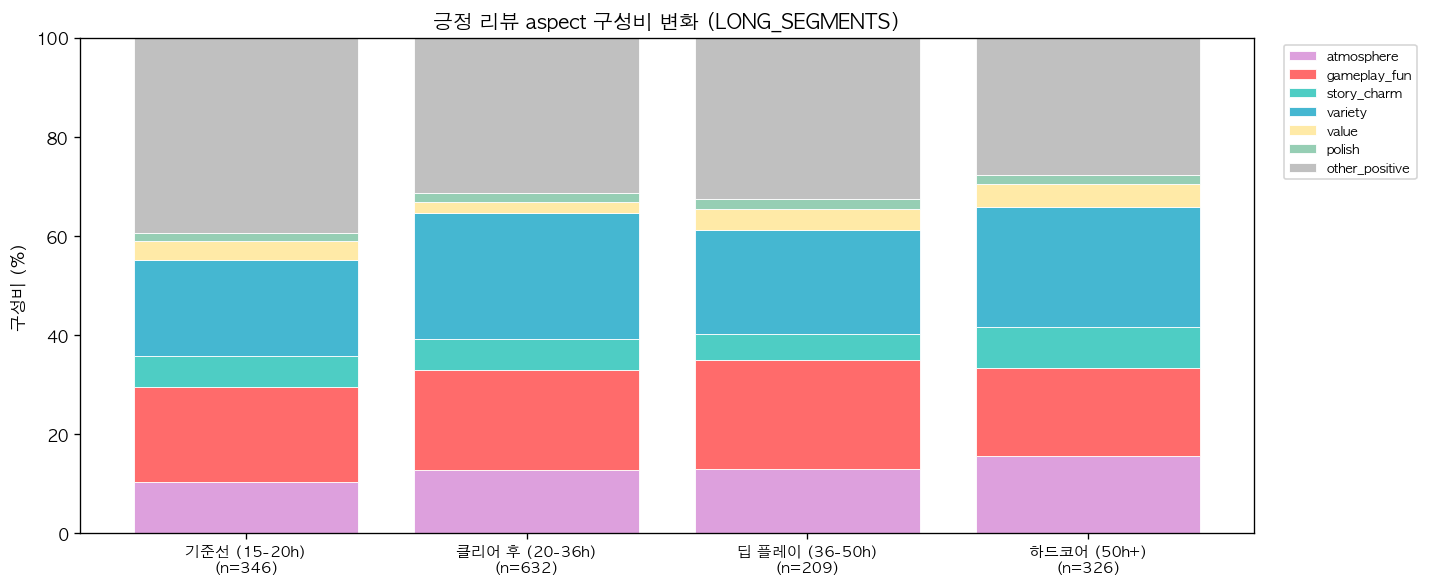

=== aspect 구성비 (%) ===
aspect      atmosphere  gameplay_fun  other_positive  polish  story_charm  value  variety
segment                                                                                  
near_clear        10.4          19.1            39.3     1.7          6.4    3.8     19.4
post_clear        12.7          20.3            31.3     1.7          6.3    2.2     25.5
deep_play         12.9          22.0            32.5     1.9          5.3    4.3     21.1
hardcore          15.6          17.8            27.6     1.8          8.3    4.6     24.2


In [15]:
# STEP 7-1. aspect 구성비 변화

pos_seg = pos_full[pos_full['segment'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 5))

aspect_ct = pd.crosstab(pos_seg['segment'], pos_seg['aspect'])
aspect_ct = aspect_ct.reindex(SEGMENT_ORDER).dropna(how='all')
aspect_pct = aspect_ct.div(aspect_ct.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(aspect_pct))
for asp in aspect_order:
    if asp in aspect_pct.columns:
        vals = aspect_pct[asp].values
        ax.bar(range(len(aspect_pct)), vals, bottom=bottom,
               color=ASPECT_COLORS.get(asp, '#888'), label=asp, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_xticks(range(len(aspect_pct)))
ax.set_xticklabels([f"{SEGMENT_LABELS_KO.get(s, s)}\n(n={aspect_ct.loc[s].sum()})" for s in aspect_pct.index],
                   fontsize=9)
ax.set_ylabel('구성비 (%)')
ax.set_ylim(0, 100)
ax.set_title('긍정 리뷰 aspect 구성비 변화 (LONG_SEGMENTS)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step7_aspect.png'), dpi=150, bbox_inches='tight')
plt.show()

# 수치 출력
print("=== aspect 구성비 (%) ===")
print(aspect_pct.round(1).to_string())

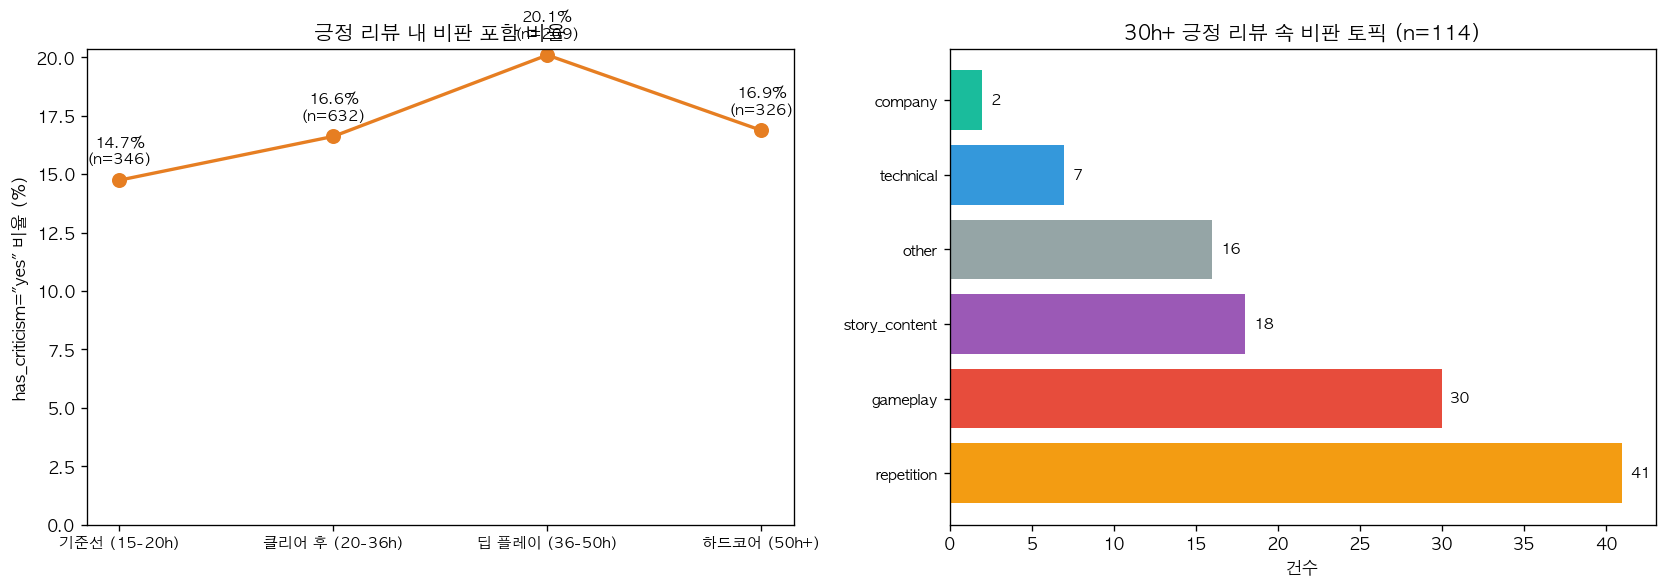

=== has_criticism 비율 ===
  기준선 (15-20h): 14.7% (346건)
  클리어 후 (20-36h): 16.6% (632건)
  딥 플레이 (36-50h): 20.1% (209건)
  하드코어 (50h+): 16.9% (326건)


In [16]:
# STEP 7-2. has_criticism 비율 + criticism_topic

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 좌: has_criticism 비율 변화
crit_rate = pos_seg.groupby('segment').apply(
    lambda x: (x['has_criticism'] == 'yes').mean() * 100
).reindex(SEGMENT_ORDER).dropna()

ax1.plot(range(len(crit_rate)), crit_rate.values, 'o-', color='#E67E22', linewidth=2, markersize=8)
for i, (seg, val) in enumerate(crit_rate.items()):
    n = len(pos_seg[pos_seg['segment'] == seg])
    ax1.annotate(f'{val:.1f}%\n(n={n})', (i, val),
                 textcoords="offset points", xytext=(0, 10), fontsize=9, ha='center')
ax1.set_xticks(range(len(crit_rate)))
ax1.set_xticklabels([SEGMENT_LABELS_KO.get(s, s) for s in crit_rate.index], fontsize=9)
ax1.set_ylabel('has_criticism="yes" 비율 (%)')
ax1.set_title('긍정 리뷰 내 비판 포함 비율')
ax1.set_ylim(bottom=0)

# 우: criticism_topic 분포 (30h+ 전체)
crit_30h = pos_seg[(pos_seg['has_criticism'] == 'yes') & (pos_seg['playtime_hours'] >= 30)]
if len(crit_30h) > 0:
    topic_counts = crit_30h['criticism_topic'].value_counts()
    topic_counts = topic_counts[topic_counts.index != 'none']
    if len(topic_counts) > 0:
        colors = [CATEGORY_COLORS.get(t, '#888') for t in topic_counts.index]
        ax2.barh(range(len(topic_counts)), topic_counts.values, color=colors)
        ax2.set_yticks(range(len(topic_counts)))
        ax2.set_yticklabels(topic_counts.index, fontsize=9)
        ax2.set_xlabel('건수')
        ax2.set_title(f'30h+ 긍정 리뷰 속 비판 토픽 (n={len(crit_30h)})')
        for i, v in enumerate(topic_counts.values):
            ax2.text(v + 0.5, i, str(v), va='center', fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'criticism_topic 없음', ha='center', va='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, '30h+ has_criticism 데이터 없음', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step7_criticism.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== has_criticism 비율 ===")
for seg in SEGMENT_ORDER:
    sub = pos_seg[pos_seg['segment'] == seg]
    if len(sub) > 0:
        rate = (sub['has_criticism'] == 'yes').mean() * 100
        print(f"  {SEGMENT_LABELS_KO.get(seg, seg)}: {rate:.1f}% ({len(sub)}건)")

20h+ 긍정 리뷰 분류: 이탈=447, 계속=498, 중간=222


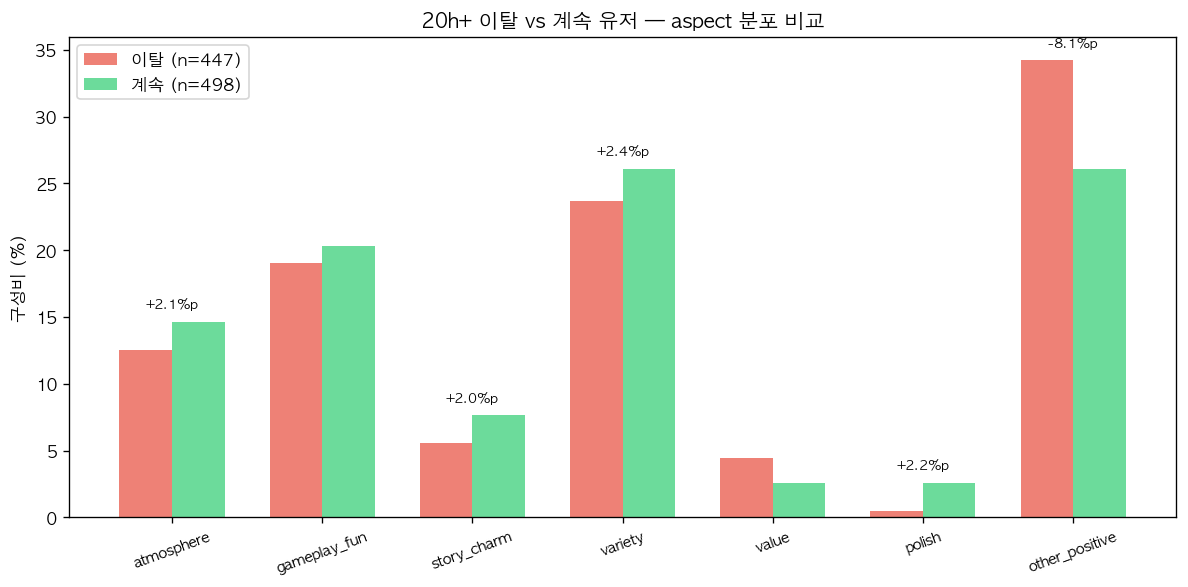


Chi-square 검정: χ²=17.46, p=0.0077
  → 이탈/계속 그룹 간 aspect 분포에 유의미한 차이 있음


In [17]:
# STEP 7-3. 이탈 vs 계속 유저 aspect 비교

# 파생 컬럼: 리뷰 후 추가 플레이타임 (시간)
pos_seg['post_review_hours'] = (pos_seg['playtime_forever'] / 60) - pos_seg['playtime_hours']

# 이탈/계속 분류 (20h+ 유저만 대상)
pos_20h = pos_seg[pos_seg['playtime_hours'] >= 20].copy()
pos_20h['user_type'] = 'middle'
pos_20h.loc[pos_20h['post_review_hours'] < 2, 'user_type'] = '이탈 (<2h 추가)'
pos_20h.loc[pos_20h['post_review_hours'] >= 10, 'user_type'] = '계속 (10h+ 추가)'

churn = pos_20h[pos_20h['user_type'] == '이탈 (<2h 추가)']
stay = pos_20h[pos_20h['user_type'] == '계속 (10h+ 추가)']

print(f"20h+ 긍정 리뷰 분류: 이탈={len(churn)}, 계속={len(stay)}, 중간={len(pos_20h) - len(churn) - len(stay)}")

if len(churn) >= 10 and len(stay) >= 10:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    churn_asp = churn['aspect'].value_counts(normalize=True).reindex(aspect_order).fillna(0) * 100
    stay_asp = stay['aspect'].value_counts(normalize=True).reindex(aspect_order).fillna(0) * 100
    
    x = np.arange(len(aspect_order))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, churn_asp.values, width, label=f'이탈 (n={len(churn)})',
                   color='#E74C3C', alpha=0.7)
    bars2 = ax.bar(x + width/2, stay_asp.values, width, label=f'계속 (n={len(stay)})',
                   color='#2ECC71', alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(aspect_order, fontsize=9, rotation=20)
    ax.set_ylabel('구성비 (%)')
    ax.set_title('20h+ 이탈 vs 계속 유저 — aspect 분포 비교')
    ax.legend()
    
    # 차이 값 표시
    for i in range(len(aspect_order)):
        diff = stay_asp.values[i] - churn_asp.values[i]
        if abs(diff) > 2:
            ax.annotate(f'{diff:+.1f}%p', (x[i], max(churn_asp.values[i], stay_asp.values[i]) + 1),
                        ha='center', fontsize=8, color='black')
    
    plt.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'long_player_step7_churn_vs_stay.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Chi-square 검정
    ct = pd.crosstab(pos_20h[pos_20h['user_type'].isin(['이탈 (<2h 추가)', '계속 (10h+ 추가)'])]['user_type'],
                     pos_20h[pos_20h['user_type'].isin(['이탈 (<2h 추가)', '계속 (10h+ 추가)'])]['aspect'])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p, dof, expected = chi2_contingency(ct)
        print(f"\nChi-square 검정: χ²={chi2:.2f}, p={p:.4f}")
        if p < 0.05:
            print("  → 이탈/계속 그룹 간 aspect 분포에 유의미한 차이 있음")
        else:
            print("  → 이탈/계속 그룹 간 aspect 분포에 유의미한 차이 없음")
else:
    print("⚠️ 이탈 또는 계속 그룹의 건수가 10건 미만 → 비교 분석 생략")

---
## STEP 8. 영어 vs 한국어 교차 비교 (버터플라이)

**목적:** 같은 장시간 유저인데, 한국 유저가 유독 다르게 반응하는 category/aspect 식별  
**시각화:** 버터플라이 차트 (왼쪽=영어, 오른쪽=한국어)

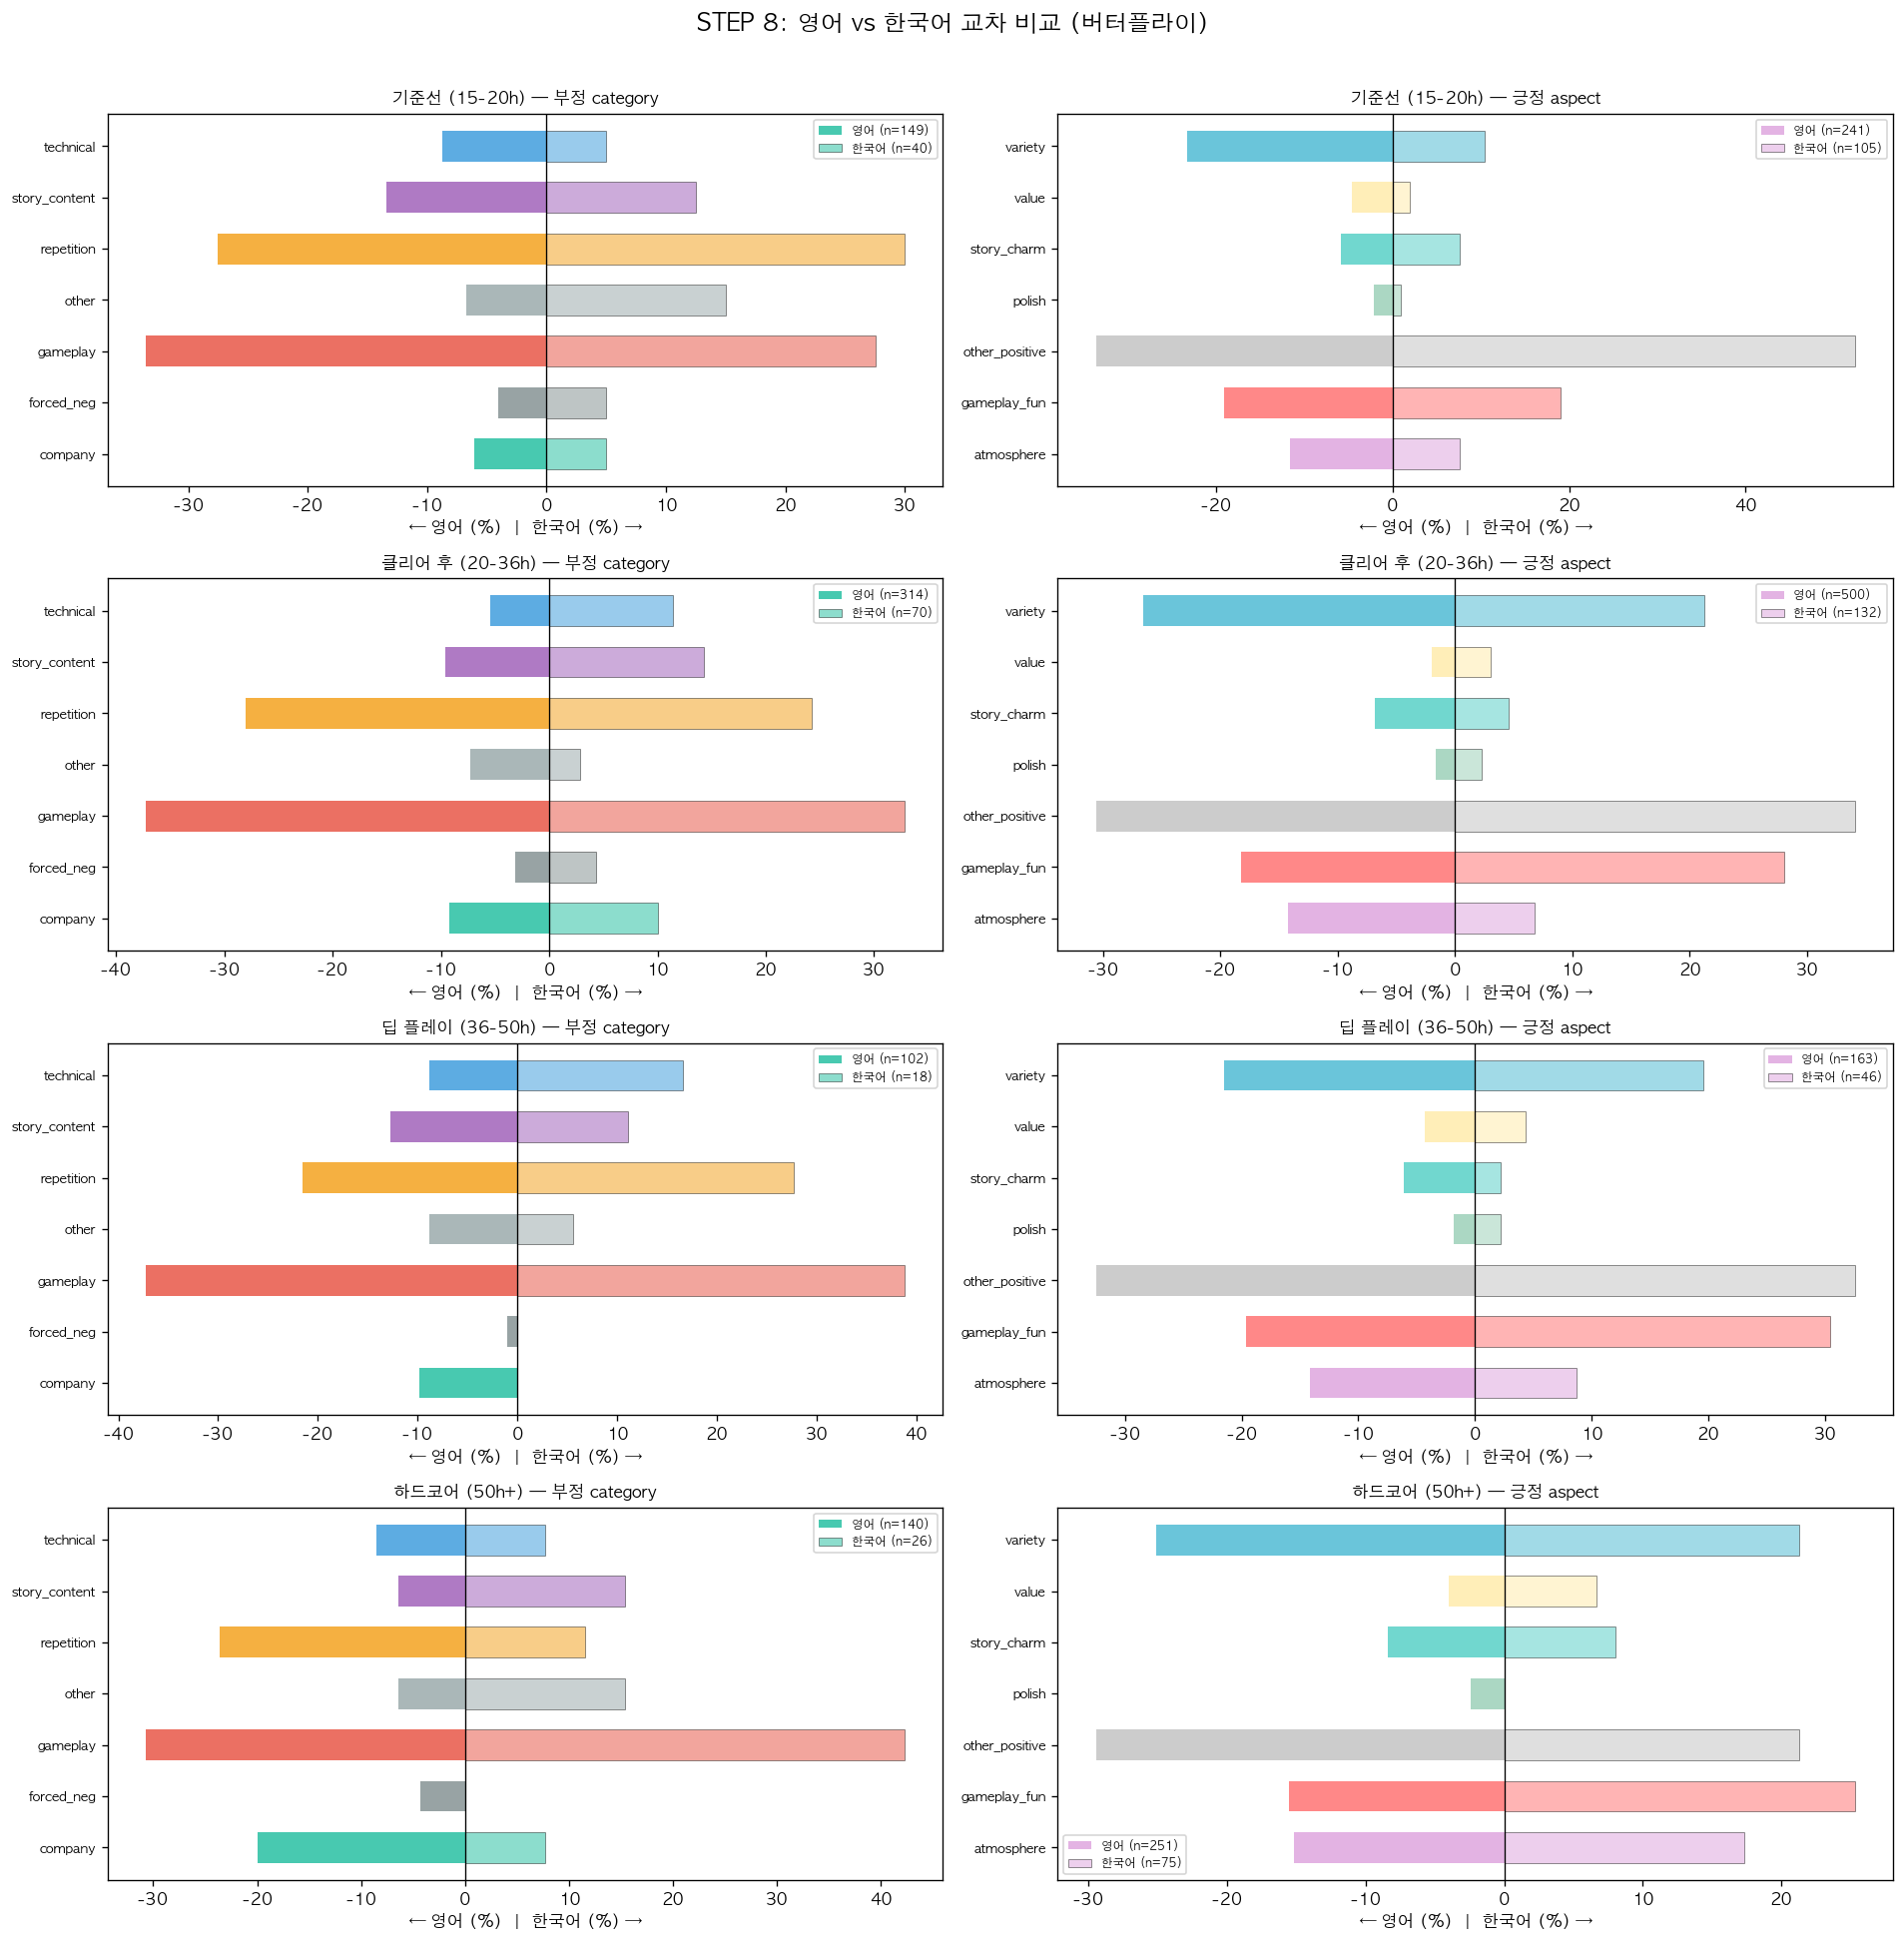

In [18]:
# STEP 8. 버터플라이 차트 (영어 vs 한국어)

n_segs = len(SEGMENT_ORDER)
fig, axes = plt.subplots(n_segs, 2, figsize=(16, 4 * n_segs))
if n_segs == 1:
    axes = axes.reshape(1, -1)

for row_idx, seg in enumerate(SEGMENT_ORDER):
    seg_label = SEGMENT_LABELS_KO.get(seg, seg)
    
    # 좌: category 버터플라이 (부정)
    ax_cat = axes[row_idx, 0]
    neg_en_s = neg_full[(neg_full['language_group'] == 'english') & (neg_full['segment'] == seg)]
    neg_ko_s = neg_full[(neg_full['language_group'] == 'korean') & (neg_full['segment'] == seg)]
    
    cats_available = sorted(set(neg_en_s['category'].unique()) | set(neg_ko_s['category'].unique()))
    if not cats_available:
        cats_available = cat_order
    
    en_pct = neg_en_s['category'].value_counts(normalize=True).reindex(cats_available).fillna(0) * 100
    ko_pct = neg_ko_s['category'].value_counts(normalize=True).reindex(cats_available).fillna(0) * 100
    
    y = np.arange(len(cats_available))
    ax_cat.barh(y, -en_pct.values, height=0.6, color=[CATEGORY_COLORS.get(c, '#888') for c in cats_available],
                alpha=0.8, label=f'영어 (n={len(neg_en_s)})')
    ax_cat.barh(y, ko_pct.values, height=0.6, color=[CATEGORY_COLORS.get(c, '#888') for c in cats_available],
                alpha=0.5, edgecolor='black', linewidth=0.5, label=f'한국어 (n={len(neg_ko_s)})')
    
    ax_cat.set_yticks(y)
    ax_cat.set_yticklabels(cats_available, fontsize=8)
    ax_cat.axvline(x=0, color='black', linewidth=0.8)
    ax_cat.set_xlabel('← 영어 (%)  |  한국어 (%) →')
    ax_cat.set_title(f'{seg_label} — 부정 category', fontsize=10)
    ax_cat.legend(fontsize=7)
    
    # 우: aspect 버터플라이 (긍정)
    ax_asp = axes[row_idx, 1]
    pos_en_s = pos_full[(pos_full['language_group'] == 'english') & (pos_full['segment'] == seg)]
    pos_ko_s = pos_full[(pos_full['language_group'] == 'korean') & (pos_full['segment'] == seg)]
    
    asps_available = sorted(set(pos_en_s['aspect'].unique()) | set(pos_ko_s['aspect'].unique()))
    if not asps_available:
        asps_available = aspect_order
    
    en_asp_pct = pos_en_s['aspect'].value_counts(normalize=True).reindex(asps_available).fillna(0) * 100
    ko_asp_pct = pos_ko_s['aspect'].value_counts(normalize=True).reindex(asps_available).fillna(0) * 100
    
    y2 = np.arange(len(asps_available))
    ax_asp.barh(y2, -en_asp_pct.values, height=0.6,
                color=[ASPECT_COLORS.get(a, '#888') for a in asps_available],
                alpha=0.8, label=f'영어 (n={len(pos_en_s)})')
    ax_asp.barh(y2, ko_asp_pct.values, height=0.6,
                color=[ASPECT_COLORS.get(a, '#888') for a in asps_available],
                alpha=0.5, edgecolor='black', linewidth=0.5, label=f'한국어 (n={len(pos_ko_s)})')
    
    ax_asp.set_yticks(y2)
    ax_asp.set_yticklabels(asps_available, fontsize=8)
    ax_asp.axvline(x=0, color='black', linewidth=0.8)
    ax_asp.set_xlabel('← 영어 (%)  |  한국어 (%) →')
    ax_asp.set_title(f'{seg_label} — 긍정 aspect', fontsize=10)
    ax_asp.legend(fontsize=7)

plt.suptitle('STEP 8: 영어 vs 한국어 교차 비교 (버터플라이)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(figures_dir, 'long_player_step8_butterfly.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 9. 인사이트 종합

### 9-1. 구간별 프로파일 카드 (코드 자동 생성)

In [ ]:
# STEP 9-1. 구간별 프로파일 카드 (자동 생성)
from IPython.display import display, Markdown

for seg in SEGMENT_ORDER:
    lo, hi = LONG_SEGMENTS[seg]
    hi_str = f"{hi}h" if hi < 9999 else "∞"
    label = SEGMENT_LABELS_KO.get(seg, seg)
    
    # 전문 데이터 건수
    en_n = len(full_en[full_en['segment'] == seg])
    ko_n = len(full_ko[full_ko['segment'] == seg])
    
    # 긍정 aspect Top3
    pos_s = pos_full[(pos_full['segment'] == seg) & (pos_full['language_group'] == 'english')]
    if len(pos_s) > 0:
        asp_top3 = pos_s['aspect'].value_counts(normalize=True).head(3)
        asp_str = ' / '.join([f"{a} ({v*100:.0f}%)" for a, v in asp_top3.items()])
    else:
        asp_str = '(데이터 부족)'
    
    # 부정 category Top3
    neg_s = neg_full[(neg_full['segment'] == seg) & (neg_full['language_group'] == 'english')]
    if len(neg_s) > 0:
        cat_top3 = neg_s['category'].value_counts(normalize=True).head(3)
        cat_str = ' / '.join([f"{c} ({v*100:.0f}%)" for c, v in cat_top3.items()])
    else:
        cat_str = '(데이터 부족)'
    
    # tone 분포
    if len(neg_s) > 0:
        tone_dist = neg_s['tone'].value_counts(normalize=True)
        tone_str = ' / '.join([f"{t} {v*100:.0f}%" for t, v in tone_dist.items()])
    else:
        tone_str = '(데이터 부족)'
    
    # has_criticism
    pos_s_all = pos_full[pos_full['segment'] == seg]
    if len(pos_s_all) > 0:
        crit_rate = (pos_s_all['has_criticism'] == 'yes').mean() * 100
        crit_topics = pos_s_all[pos_s_all['has_criticism'] == 'yes']['criticism_topic'].value_counts().head(3)
        crit_topics_str = ', '.join([f"{t}" for t in crit_topics.index if t != 'none'][:3])
        crit_str = f"{crit_rate:.0f}%, 주요: {crit_topics_str}" if crit_topics_str else f"{crit_rate:.0f}%"
    else:
        crit_str = '(데이터 부족)'
    
    # 특징 키워드
    kw = keyword_results_en.get(seg, pd.DataFrame())
    if len(kw) > 0:
        kw_str = ', '.join(kw['keyword'].head(5).tolist())
    else:
        kw_str = '(데이터 부족)'
    
    # 특이점
    notes = []
    if len(neg_s) > 0:
        pbnv_rate = (neg_s['actual_sentiment'] == 'positive_but_negative_vote').mean() * 100
        if pbnv_rate > 15:
            notes.append(f"positive_but_neg_vote {pbnv_rate:.0f}%")
        rep_rate = (neg_s['category'] == 'repetition').mean() * 100
        if rep_rate > 20:
            notes.append(f"repetition 불만 집중 ({rep_rate:.0f}%)")
    notes_str = '; '.join(notes) if notes else '-'
    
    md = f"""
## [{label}] {lo}h ~ {hi_str}  (전문EN={en_n:,} / 전문KO={ko_n:,})

| 항목 | 내용 |
|------|------|
| 주요 칭찬 (Top3) | {asp_str} |
| 주요 불만 (Top3) | {cat_str} |
| 비판 tone | {tone_str} |
| 숨겨진 불만 | has_criticism='yes' {crit_str} |
| 특징 키워드 | {kw_str} |
| 특이점 | {notes_str} |
"""
    display(Markdown(md))


## [기준선 (15-20h)] 15h ~ 20h  (전문EN=3,715 / 전문KO=1,089)

| 항목 | 내용 |
|------|------|
| 주요 칭찬 (Top3) | other_positive (34%) / variety (23%) / gameplay_fun (19%) |
| 주요 불만 (Top3) | gameplay (34%) / repetition (28%) / story_content (13%) |
| 비판 tone | constructive 60% / emotional 21% / mixed 15% / troll 3% |
| 숨겨진 불만 | has_criticism='yes' 15%, 주요: gameplay, repetition, technical |
| 특징 키워드 | fish, fun, access, early, wait |
| 특이점 | repetition 불만 집중 (28%) |



## [클리어 후 (20-36h)] 20h ~ 36h  (전문EN=9,528 / 전문KO=2,187)

| 항목 | 내용 |
|------|------|
| 주요 칭찬 (Top3) | other_positive (31%) / variety (27%) / gameplay_fun (18%) |
| 주요 불만 (Top3) | gameplay (37%) / repetition (28%) / story_content (10%) |
| 비판 tone | constructive 72% / emotional 14% / mixed 12% / troll 3% |
| 숨겨진 불만 | has_criticism='yes' 17%, 주요: repetition, gameplay, other |
| 특징 키워드 | amazing, diving, release, mechanic, chill |
| 특이점 | repetition 불만 집중 (28%) |



## [딥 플레이 (36-50h)] 36h ~ 50h  (전문EN=5,506 / 전문KO=1,065)

| 항목 | 내용 |
|------|------|
| 주요 칭찬 (Top3) | other_positive (33%) / variety (21%) / gameplay_fun (20%) |
| 주요 불만 (Top3) | gameplay (37%) / repetition (22%) / story_content (13%) |
| 비판 tone | constructive 67% / emotional 16% / mixed 16% / troll 2% |
| 숨겨진 불만 | has_criticism='yes' 20%, 주요: repetition, gameplay, story_content |
| 특징 키워드 | story, experience, amazing, main, wonderful |
| 특이점 | repetition 불만 집중 (22%) |



## [하드코어 (50h+)] 50h ~ ∞  (전문EN=6,931 / 전문KO=1,298)

| 항목 | 내용 |
|------|------|
| 주요 칭찬 (Top3) | other_positive (29%) / variety (25%) / gameplay_fun (16%) |
| 주요 불만 (Top3) | gameplay (31%) / repetition (24%) / company (20%) |
| 비판 tone | constructive 58% / emotional 20% / mixed 19% / troll 4% |
| 숨겨진 불만 | has_criticism='yes' 17%, 주요: repetition, gameplay, other |
| 특징 키워드 | love, achievement, dlc, fun, enjoy |
| 특이점 | repetition 불만 집중 (24%) |


In [20]:
# 9-2. 30h+ 건설적 비판 category 우선순위

constructive_30h_all = neg_full[
    (neg_full['tone'] == 'constructive') & 
    (neg_full['playtime_hours'] >= 30) &
    (neg_full['language_group'] == 'english')
]

if len(constructive_30h_all) > 0:
    priority = constructive_30h_all['category'].value_counts()
    print("=== 30h+ 건설적 비판 category 우선순위 ===")
    for cat, cnt in priority.items():
        pct = cnt / len(constructive_30h_all) * 100
        print(f"  {cat:20s}: {cnt}건 ({pct:.1f}%)")
    
    # sub_category 확인
    print("\n=== 30h+ 건설적 비판 sub_category (Top 10) ===")
    sub_cats = constructive_30h_all['sub_category'].value_counts().head(10)
    for sc, cnt in sub_cats.items():
        if sc != 'none':
            print(f"  {sc:30s}: {cnt}건")
else:
    print("30h+ constructive 데이터 없음")

=== 30h+ 건설적 비판 category 우선순위 ===
  gameplay            : 76건 (35.8%)
  repetition          : 69건 (32.5%)
  company             : 22건 (10.4%)
  story_content       : 17건 (8.0%)
  technical           : 16건 (7.5%)
  other               : 8건 (3.8%)
  forced_neg          : 4건 (1.9%)

=== 30h+ 건설적 비판 sub_category (Top 10) ===
  gameplay                      : 44건
  story_content                 : 19건
  repetition                    : 14건
  technical                     : 5건
  company                       : 3건
  other                         : 1건


In [22]:
# DB 연결 종료
conn.close()
print("DB 연결 종료")

DB 연결 종료
